In [1]:
"""
Wandb Results Visualization: Abstral vs CoT
============================================
Comparing Abstral (abstract tokens) vs Chain-of-Thought methods
across online and offline datasets with various hyperparameters.
"""

import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Create results folder
RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

# Color maps
color_maps = {
    "colors3": ["#AE2012", "#023047", "#FFB703"],
    "colors5a": ["#023047", "#8ECAE6", "#E9C46A", "#F67E4B", "#AE2012"],
    "colors5l": ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"],
    "colors5": ["#8ECAE6", "#219EBC", "#023047", "#FFB703", "#FB8500"],
    "colors8": ["#005F73", "#0A9396", "#94D2BD", "#E9D8A6", "#EE9B00", "#CA6702", "#BB3E03", "#AE2012"],
    "colors9": ["#001219", "#005F73", "#0A9396", "#94D2BD", "#FFB703", "#CA6702", "#BB3E03", "#AE2012", "#9B2226"],
    "colors10": ["#001219", "#005F73", "#0A9396", "#94D2BD", "#E9D8A6", "#EE9B00", "#CA6702", "#BB3E03", "#AE2012", "#9B2226"],
    "blues": ["#001219", "#005F73", "#0A9396", "#94D2BD", "#E9D8A6"],
    "colorsblind10": ["#364B9A", "#E8EFF6", "#6EA5CD", "#97CAE1", "#C2E4EE", "#EAECCC", "#FEDA8A", "#FDB366", "#F67E4B", "#DD3C2D"]
}

# Use colors from color_maps for Abstral vs CoT
# Abstral: blues (from colors5a first color - dark blue)
# CoT: warm colors (from colors5a last color - red)
COLORS = {
    'abstral': "#023047",      # Dark blue
    'cot': "#AE2012",          # Dark red
    'abstral_light': "#8ECAE6", # Light blue
    'cot_light': "#F67E4B",    # Orange
}

# Gradient colors for varying parameters
ABSTRAL_GRADIENT = color_maps["blues"]  # For different n_abstral_tokens
COT_GRADIENT = ["#FFB703", "#EE9B00", "#CA6702", "#BB3E03", "#AE2012"]  # For different max_entities

# --- Styling ---
%matplotlib inline
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"],
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
plt.rc('text', usetex=False)
plt.rc('font', family='serif')

def save_plot(fig, name):
    """Save plot to results folder in both PNG and PDF."""
    fig.savefig(RESULTS_DIR / f"{name}.png", dpi=300, bbox_inches='tight', facecolor='white')
    fig.savefig(RESULTS_DIR / f"{name}.pdf", bbox_inches='tight', facecolor='white')
    print(f"Saved: {RESULTS_DIR}/{name}.png and {RESULTS_DIR}/{name}.pdf")

# Wandb project details
WANDB_ENTITY = "tml-abstral"
WANDB_PROJECT = "abstral_vs_cot_vocab_new_outsize_fixed_shuffling"

print(f"Connecting to wandb project: {WANDB_ENTITY}/{WANDB_PROJECT}")
print(f"Results will be saved to: {RESULTS_DIR.absolute()}")

Connecting to wandb project: tml-abstral/abstral_vs_cot_vocab_new_outsize_fixed_shuffling
Results will be saved to: /tmlscratch/dngfra/coconut/notebooks/results


In [2]:
# Color maps and styling are now defined in cell 0 above
# This cell can be deleted

In [3]:
# Styling is now defined in cell 0 above
# This cell can be deleted

In [4]:
# Fetch all runs from wandb
api = wandb.Api()
runs = api.runs(f"{WANDB_ENTITY}/{WANDB_PROJECT}")

print(f"Found {len(runs)} runs in project")

# Helper function to safely get nested config values
def safe_get(d, *keys, default=None):
    """Safely navigate nested dictionaries."""
    for key in keys:
        if isinstance(d, dict):
            d = d.get(key, default)
        else:
            return default
    return d if d is not None else default

# Extract run data into a list of dictionaries
run_data = []

for run in runs:
    # Include all runs (finished, running, etc.) - only skip failed/crashed
    if run.state in ["crashed", "failed"]:
        continue
    
    config = run.config
    
    # Extract key configuration parameters
    # Based on actual config structure:
    # - abstral, n_abstral_tokens are top-level
    # - dataset is a nested dict containing online, max_entities, max_names, size, unified_names_entities
    # - model_config_overrides is a nested dict
    try:
        dataset_config = config.get('dataset', {})
        model_overrides = config.get('model_config_overrides', {})
        
        run_info = {
            'run_id': run.id,
            'run_name': run.name,
            'state': run.state,
            
            # Method parameters (top-level)
            'abstral': config.get('abstral', False),
            'n_abstral_tokens': config.get('n_abstral_tokens', None),
            
            # Data parameters (nested in 'dataset')
            'online': dataset_config.get('online', None) if isinstance(dataset_config, dict) else None,
            'unified_names_entities': dataset_config.get('unified_names_entities', None) if isinstance(dataset_config, dict) else None,
            'max_entities': dataset_config.get('max_entities', None) if isinstance(dataset_config, dict) else None,
            'max_names': dataset_config.get('max_names', None) if isinstance(dataset_config, dict) else None,
            'dataset_size': safe_get(dataset_config, 'size', 'train', default=None),
            
            # Model parameters (nested in 'model_config_overrides')
            'n_layer': model_overrides.get('n_layer', None) if isinstance(model_overrides, dict) else None,
            'n_embd': model_overrides.get('n_embd', None) if isinstance(model_overrides, dict) else None,
        }
        
        # Get summary metrics (final values)
        summary = run.summary
        run_info['final_acc'] = summary.get('eval/acc', None)
        run_info['final_acc_1'] = summary.get('eval/acc_1', None)
        run_info['final_cot_em'] = summary.get('eval/cot_em', None)
        run_info['final_loss'] = summary.get('eval/loss', None)
        run_info['final_train_loss'] = summary.get('train/loss', None)
        
        run_data.append(run_info)
        
    except Exception as e:
        print(f"Error processing run {run.id}: {e}")
        import traceback
        traceback.print_exc()
        continue

# Create DataFrame
df_all = pd.DataFrame(run_data)
print(f"\nSuccessfully loaded {len(df_all)} runs (including running)")

# Show state distribution
print(f"Run states: {df_all['state'].value_counts().to_dict()}")

# Filter to only include runs with unified_names_entities = True
df = df_all[df_all['unified_names_entities'] == True].copy()
print(f"Runs with unified_names_entities=True: {len(df)} out of {len(df_all)}")

# Show data overview
print("\nFiltered data sample:")
print(df[['abstral', 'n_abstral_tokens', 'online', 'max_entities', 'dataset_size', 'final_acc']].to_string())

df.head()

Found 40 runs in project

Successfully loaded 26 runs (including running)
Run states: {'running': 18, 'finished': 8}
Runs with unified_names_entities=True: 26 out of 26

Filtered data sample:
    abstral  n_abstral_tokens  online  max_entities  dataset_size  final_acc
0     False               100    True           500         17886   0.620000
1     False               100    True          2500         17886   0.580000
2      True                50    True          1000         17886   0.950000
3      True               100    True          1000         17886   0.213333
4      True               250    True          1000         17886   0.030000
5     False               100    True          1500         17886   0.503333
6      True                24    True          1000         17886   0.910000
7     False               100    True          5000         17886   0.520000
8      True               500    True          1000         17886   0.013333
9     False               100    True 

,run_id,run_name,state,abstral,n_abstral_tokens,online,unified_names_entities,max_entities,max_names,dataset_size,n_layer,n_embd,final_acc,final_acc_1,final_cot_em,final_loss,final_train_loss
0,4c0828bb4f874d96,4c0828bb4f874d96,running,False,100,True,True,500,50,17886,2,128,0.620000,0.620000,0.440000,0.171802,0.183974
1,0f3a8fa04bf4aca2,0f3a8fa04bf4aca2,running,False,100,True,True,2500,50,17886,2,128,0.580000,0.580000,0.410000,0.176808,0.210797
2,11c8af4b3158e522,11c8af4b3158e522,running,True,50,True,True,1000,50,17886,2,128,0.950000,0.950000,0.823333,0.041532,0.043098
3,13daa21631a9a67d,13daa21631a9a67d,running,True,100,True,True,1000,50,17886,2,128,0.213333,0.213333,0.140000,0.079369,0.078857
4,37f5cc3b51b060ee,37f5cc3b51b060ee,running,True,250,True,True,1000,50,17886,2,128,0.030000,0.030000,0.023333,0.084726,0.087583


In [5]:
# Data preprocessing and labeling

# Separate online vs offline runs
df_online = df[df['online'] == True].copy()
df_offline = df[df['online'] == False].copy()

print(f"Online runs: {len(df_online)}")
print(f"Offline runs: {len(df_offline)}")

# Create descriptive labels for each run (handle None values)
def create_label(row):
    """Create label based on method type and key parameter."""
    if row['abstral']:
        tokens = row['n_abstral_tokens']
        if pd.notna(tokens):
            return f"Abstral ({int(tokens)} tokens)"
        else:
            return "Abstral (unknown tokens)"
    else:
        entities = row['max_entities']
        if pd.notna(entities):
            return f"CoT ({int(entities)} entities)"
        else:
            return "CoT (unknown entities)"

# Apply labels
df['label'] = df.apply(create_label, axis=1)
if len(df_online) > 0:
    df_online['label'] = df_online.apply(create_label, axis=1)
if len(df_offline) > 0:
    df_offline['label'] = df_offline.apply(create_label, axis=1)

# Create method type column
df['method_type'] = df['abstral'].map({True: 'Abstral', False: 'CoT'})
if len(df_online) > 0:
    df_online['method_type'] = df_online['abstral'].map({True: 'Abstral', False: 'CoT'})
if len(df_offline) > 0:
    df_offline['method_type'] = df_offline['abstral'].map({True: 'Abstral', False: 'CoT'})

# Display summary statistics
print("\n" + "=" * 70)
print("ONLINE DATASET SUMMARY")
print("=" * 70)
if len(df_online) > 0:
    print("\nAbstral runs (varying n_abstral_tokens):")
    abstral_online = df_online[df_online['abstral'] == True]
    if len(abstral_online) > 0:
        print(abstral_online.groupby('n_abstral_tokens')['final_acc'].agg(['mean', 'std', 'count']))
    else:
        print("  No Abstral runs")
    
    print("\nCoT runs (varying max_entities):")
    cot_online = df_online[df_online['abstral'] == False]
    if len(cot_online) > 0:
        print(cot_online.groupby('max_entities')['final_acc'].agg(['mean', 'std', 'count']))
    else:
        print("  No CoT runs")
else:
    print("No online runs found")

print("\n" + "=" * 70)
print("OFFLINE DATASET SUMMARY")
print("=" * 70)
if len(df_offline) > 0:
    print("\nAbstral runs (varying n_abstral_tokens x dataset_size):")
    abstral_offline = df_offline[df_offline['abstral'] == True]
    if len(abstral_offline) > 0:
        pivot = abstral_offline.pivot_table(values='final_acc', index='n_abstral_tokens', 
                                            columns='dataset_size', aggfunc='mean')
        print(pivot.to_string())
    else:
        print("  No Abstral runs")
    
    print("\nCoT runs (varying max_entities x dataset_size):")
    cot_offline = df_offline[df_offline['abstral'] == False]
    if len(cot_offline) > 0:
        pivot = cot_offline.pivot_table(values='final_acc', index='max_entities', 
                                        columns='dataset_size', aggfunc='mean')
        print(pivot.to_string())
    else:
        print("  No CoT runs")
else:
    print("No offline runs found")

print("\n" + "=" * 70)

Online runs: 10
Offline runs: 16

ONLINE DATASET SUMMARY

Abstral runs (varying n_abstral_tokens):
                      mean  std  count
n_abstral_tokens                      
24                0.910000  NaN      1
50                0.950000  NaN      1
100               0.213333  NaN      1
250               0.030000  NaN      1
500               0.013333  NaN      1

CoT runs (varying max_entities):
                  mean  std  count
max_entities                      
500           0.620000  NaN      1
1000          0.506667  NaN      1
1500          0.503333  NaN      1
2500          0.580000  NaN      1
5000          0.520000  NaN      1

OFFLINE DATASET SUMMARY

Abstral runs (varying n_abstral_tokens x dataset_size):
dataset_size      10000     25000     50000   100000
n_abstral_tokens                                    
24                  0.47  0.870000  0.553333    0.91
50                  0.41  0.463333  0.876667    0.85

CoT runs (varying max_entities x dataset_size):
datase

Saved: results/online_bar_comparison.png and results/online_bar_comparison.pdf


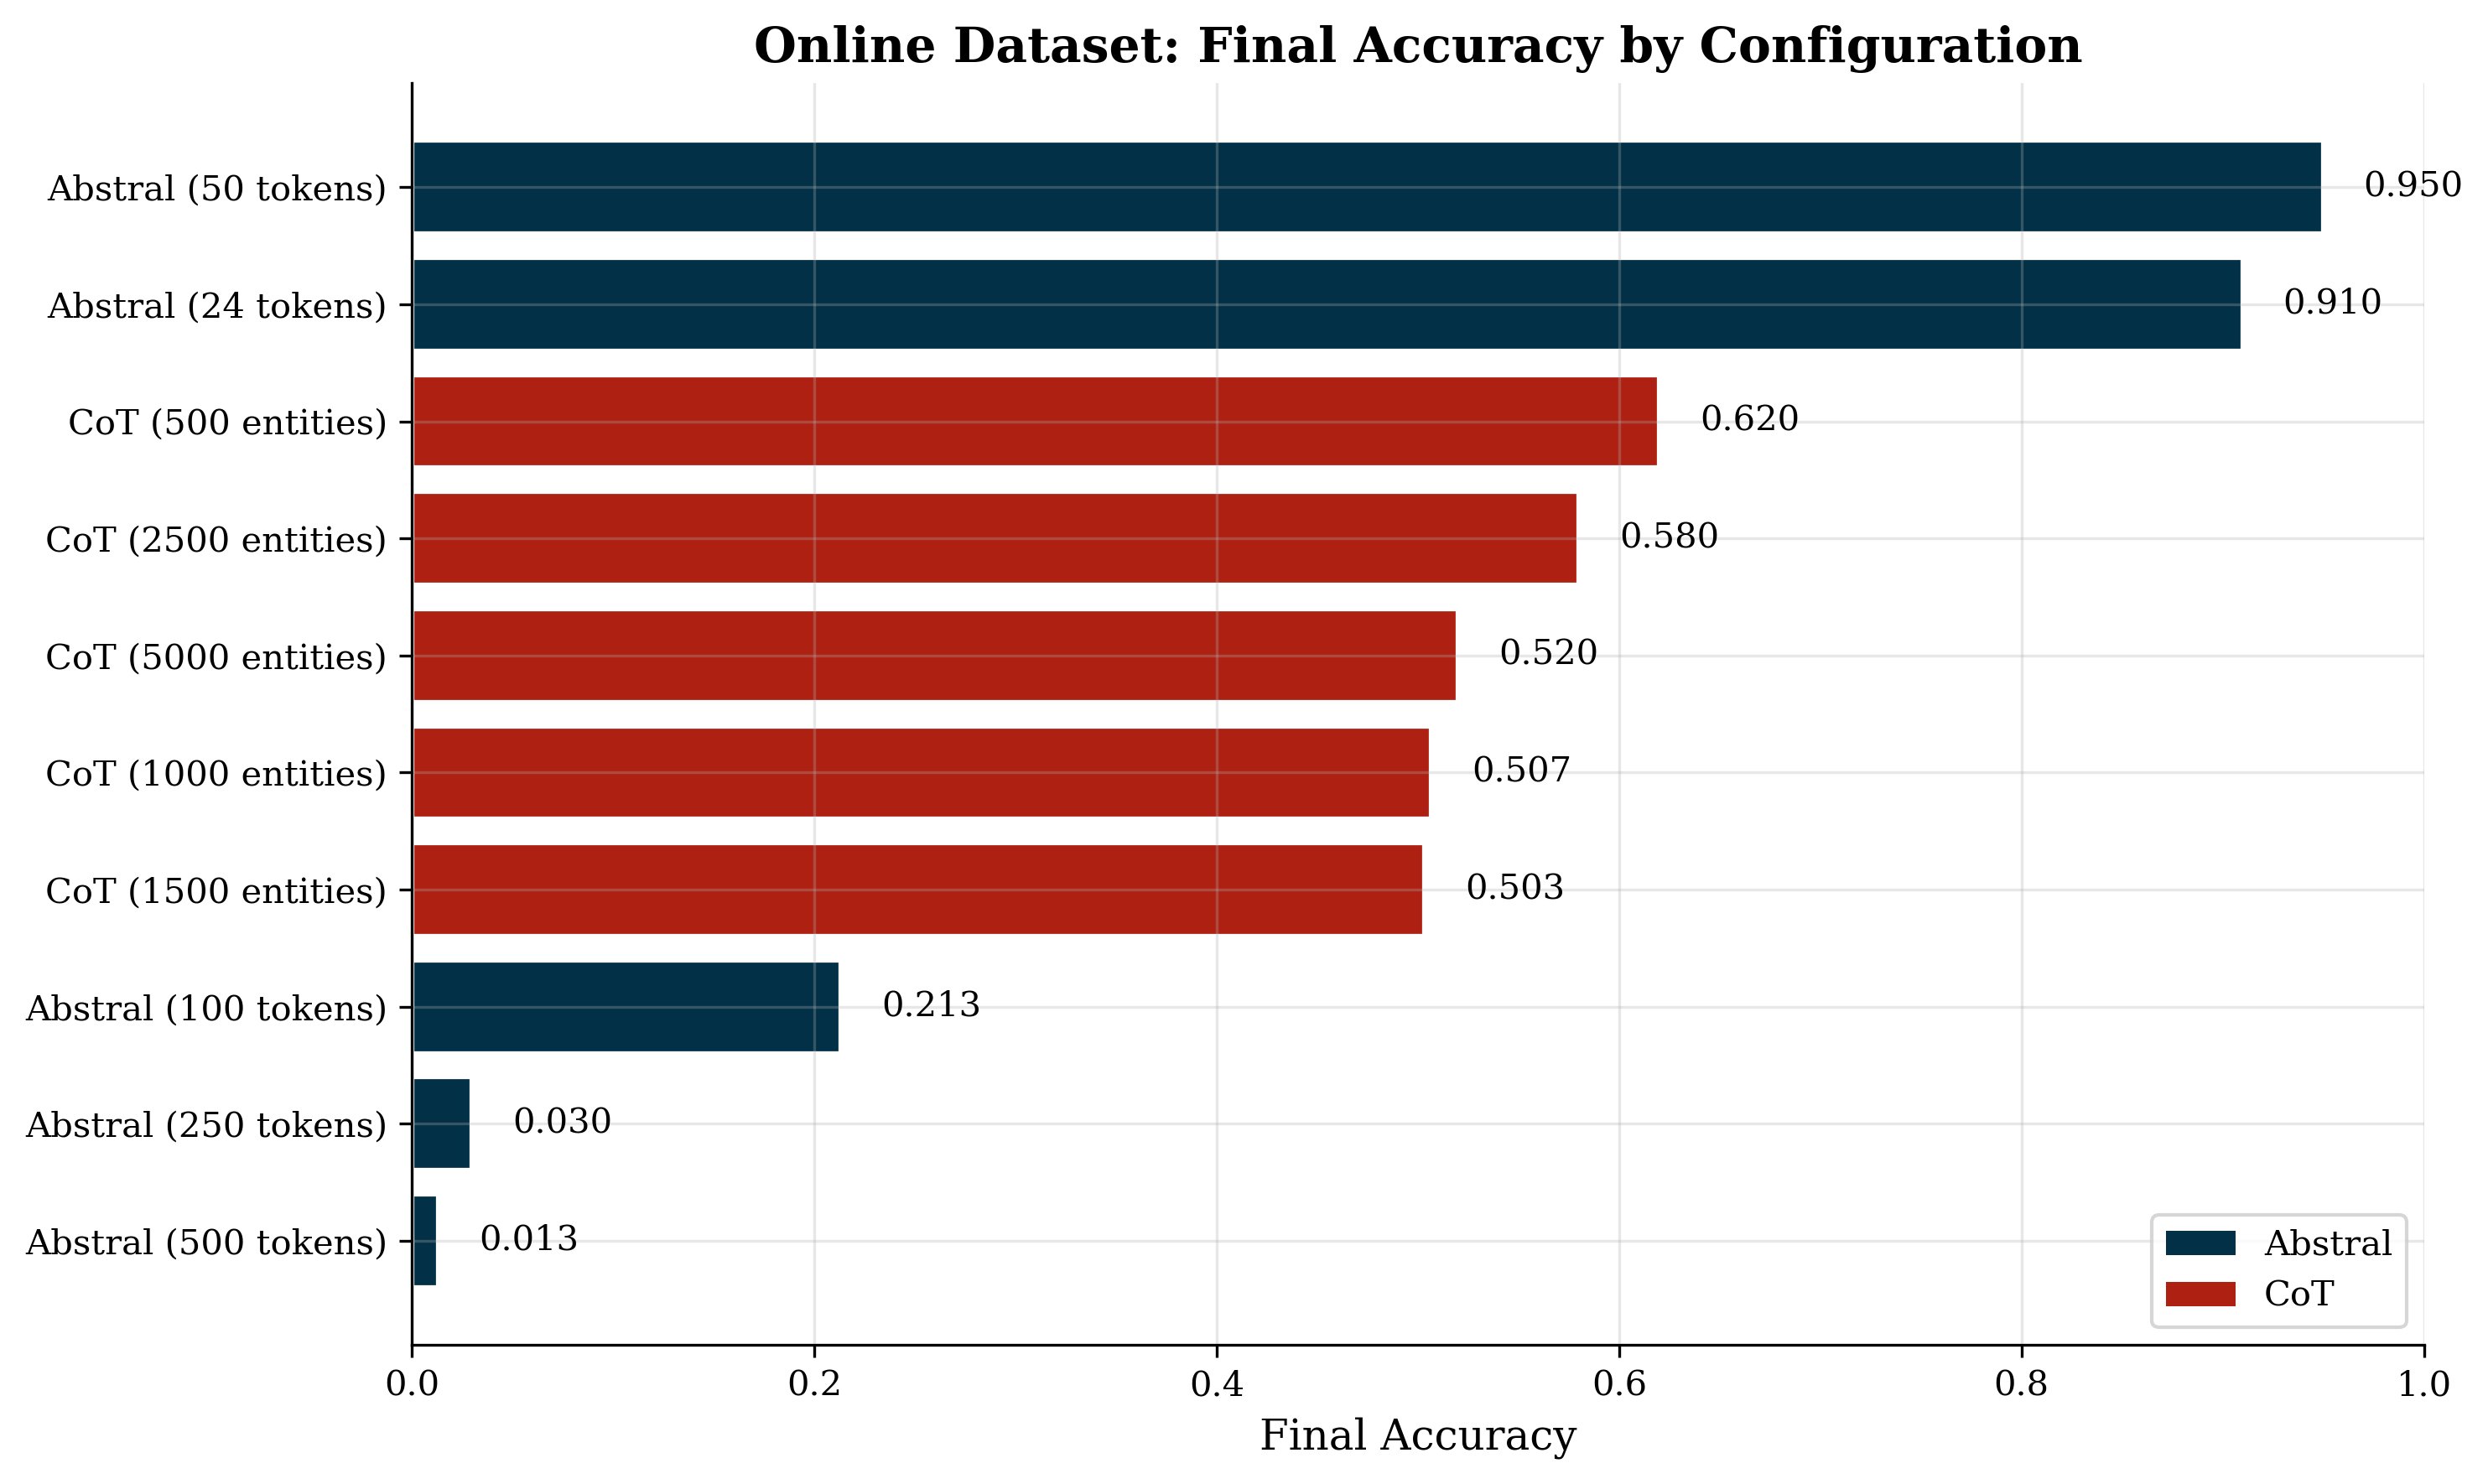

In [6]:
# =============================================================================
# ONLINE DATASET PLOTS
# =============================================================================

# Plot 1: Bar chart comparison - All configurations (Online)
if len(df_online) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for grouped bar chart
    online_summary = df_online.groupby('label')['final_acc'].agg(['mean', 'std']).reset_index()
    online_summary = online_summary.sort_values('mean', ascending=True)
    
    # Create color list based on method type using color_maps
    colors = [COLORS['abstral'] if 'Abstral' in label else COLORS['cot'] 
              for label in online_summary['label']]
    
    bars = ax.barh(
        online_summary['label'], 
        online_summary['mean'],
        xerr=online_summary['std'],
        color=colors,
        capsize=5,
        edgecolor='white',
        linewidth=1.5
    )
    
    ax.set_xlabel('Final Accuracy', fontsize=12)
    ax.set_title('Online Dataset: Final Accuracy by Configuration', fontsize=14, fontweight='bold')
    ax.set_xlim(0, 1.0)
    
    # Add value labels on bars
    for bar, val in zip(bars, online_summary['mean']):
        ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, 
                f'{val:.3f}', va='center', fontsize=10)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=COLORS['abstral'], label='Abstral'),
        Patch(facecolor=COLORS['cot'], label='CoT')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    plt.tight_layout()
    save_plot(fig, 'online_bar_comparison')
    plt.show()
else:
    print("No online data to plot")

In [7]:
# Plot 3: Training curves for online dataset (fetch history data)
# Note: This fetches detailed history which can be slower

def fetch_run_history(run_id, metrics=['eval/acc', 'train/loss', 'train/epoch']):
    """Fetch history for a specific run."""
    run = api.run(f"{WANDB_ENTITY}/{WANDB_PROJECT}/{run_id}")
    history = run.history(keys=metrics, pandas=True)
    return history

# Fetch history for a subset of representative runs (online)
# Select best run for each configuration
online_configs = df_online.groupby('label').apply(
    lambda x: x.loc[x['final_acc'].idxmax()] if len(x) > 0 else None
).dropna()

print("Fetching training histories for online runs...")
histories_online = {}
for idx, row in online_configs.iterrows():
    try:
        hist = fetch_run_history(row['run_id'])
        if len(hist) > 0:
            histories_online[row['label']] = hist
            print(f"  Loaded: {row['label']}")
    except Exception as e:
        print(f"  Failed to load {row['label']}: {e}")

print(f"\nLoaded {len(histories_online)} training histories")

Fetching training histories for online runs...

Loaded 0 training histories


In [8]:
# Plot training curves (accuracy over epochs) for online dataset
if len(histories_online) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Get unique labels and assign colors from gradients
    abstral_labels = [l for l in histories_online.keys() if 'Abstral' in l]
    cot_labels = [l for l in histories_online.keys() if 'CoT' in l]
    
    # Assign gradient colors
    label_colors = {}
    for i, label in enumerate(sorted(abstral_labels)):
        label_colors[label] = ABSTRAL_GRADIENT[i % len(ABSTRAL_GRADIENT)]
    for i, label in enumerate(sorted(cot_labels)):
        label_colors[label] = COT_GRADIENT[i % len(COT_GRADIENT)]
    
    # Plot accuracy curves
    ax1 = axes[0]
    for label, hist in histories_online.items():
        color = label_colors.get(label, COLORS['abstral'] if 'Abstral' in label else COLORS['cot'])
        if 'eval/acc' in hist.columns and 'train/epoch' in hist.columns:
            valid_mask = hist['eval/acc'].notna()
            epochs = hist.loc[valid_mask, 'train/epoch']
            acc = hist.loc[valid_mask, 'eval/acc']
            ax1.plot(epochs, acc, label=label, color=color, linewidth=2, alpha=0.8)
    
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Evaluation Accuracy', fontsize=12)
    ax1.set_title('Online Dataset: Training Curves (Accuracy)', fontsize=13, fontweight='bold')
    ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax1.set_ylim(0, 1.0)
    
    # Plot loss curves
    ax2 = axes[1]
    for label, hist in histories_online.items():
        color = label_colors.get(label, COLORS['abstral'] if 'Abstral' in label else COLORS['cot'])
        if 'train/loss' in hist.columns and 'train/epoch' in hist.columns:
            valid_mask = hist['train/loss'].notna()
            epochs = hist.loc[valid_mask, 'train/epoch']
            loss = hist.loc[valid_mask, 'train/loss']
            window = max(1, len(loss) // 100)
            if window > 1:
                loss_smooth = loss.rolling(window=window, min_periods=1).mean()
            else:
                loss_smooth = loss
            ax2.plot(epochs, loss_smooth, label=label, color=color, linewidth=2, alpha=0.8)
    
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Training Loss', fontsize=12)
    ax2.set_title('Online Dataset: Training Curves (Loss)', fontsize=13, fontweight='bold')
    ax2.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    ax2.set_yscale('log')
    
    plt.tight_layout()
    save_plot(fig, 'online_training_curves')
    plt.show()
else:
    print("No training histories loaded for online dataset")

No training histories loaded for online dataset


Saved: results/offline_accuracy_vs_size.png and results/offline_accuracy_vs_size.pdf


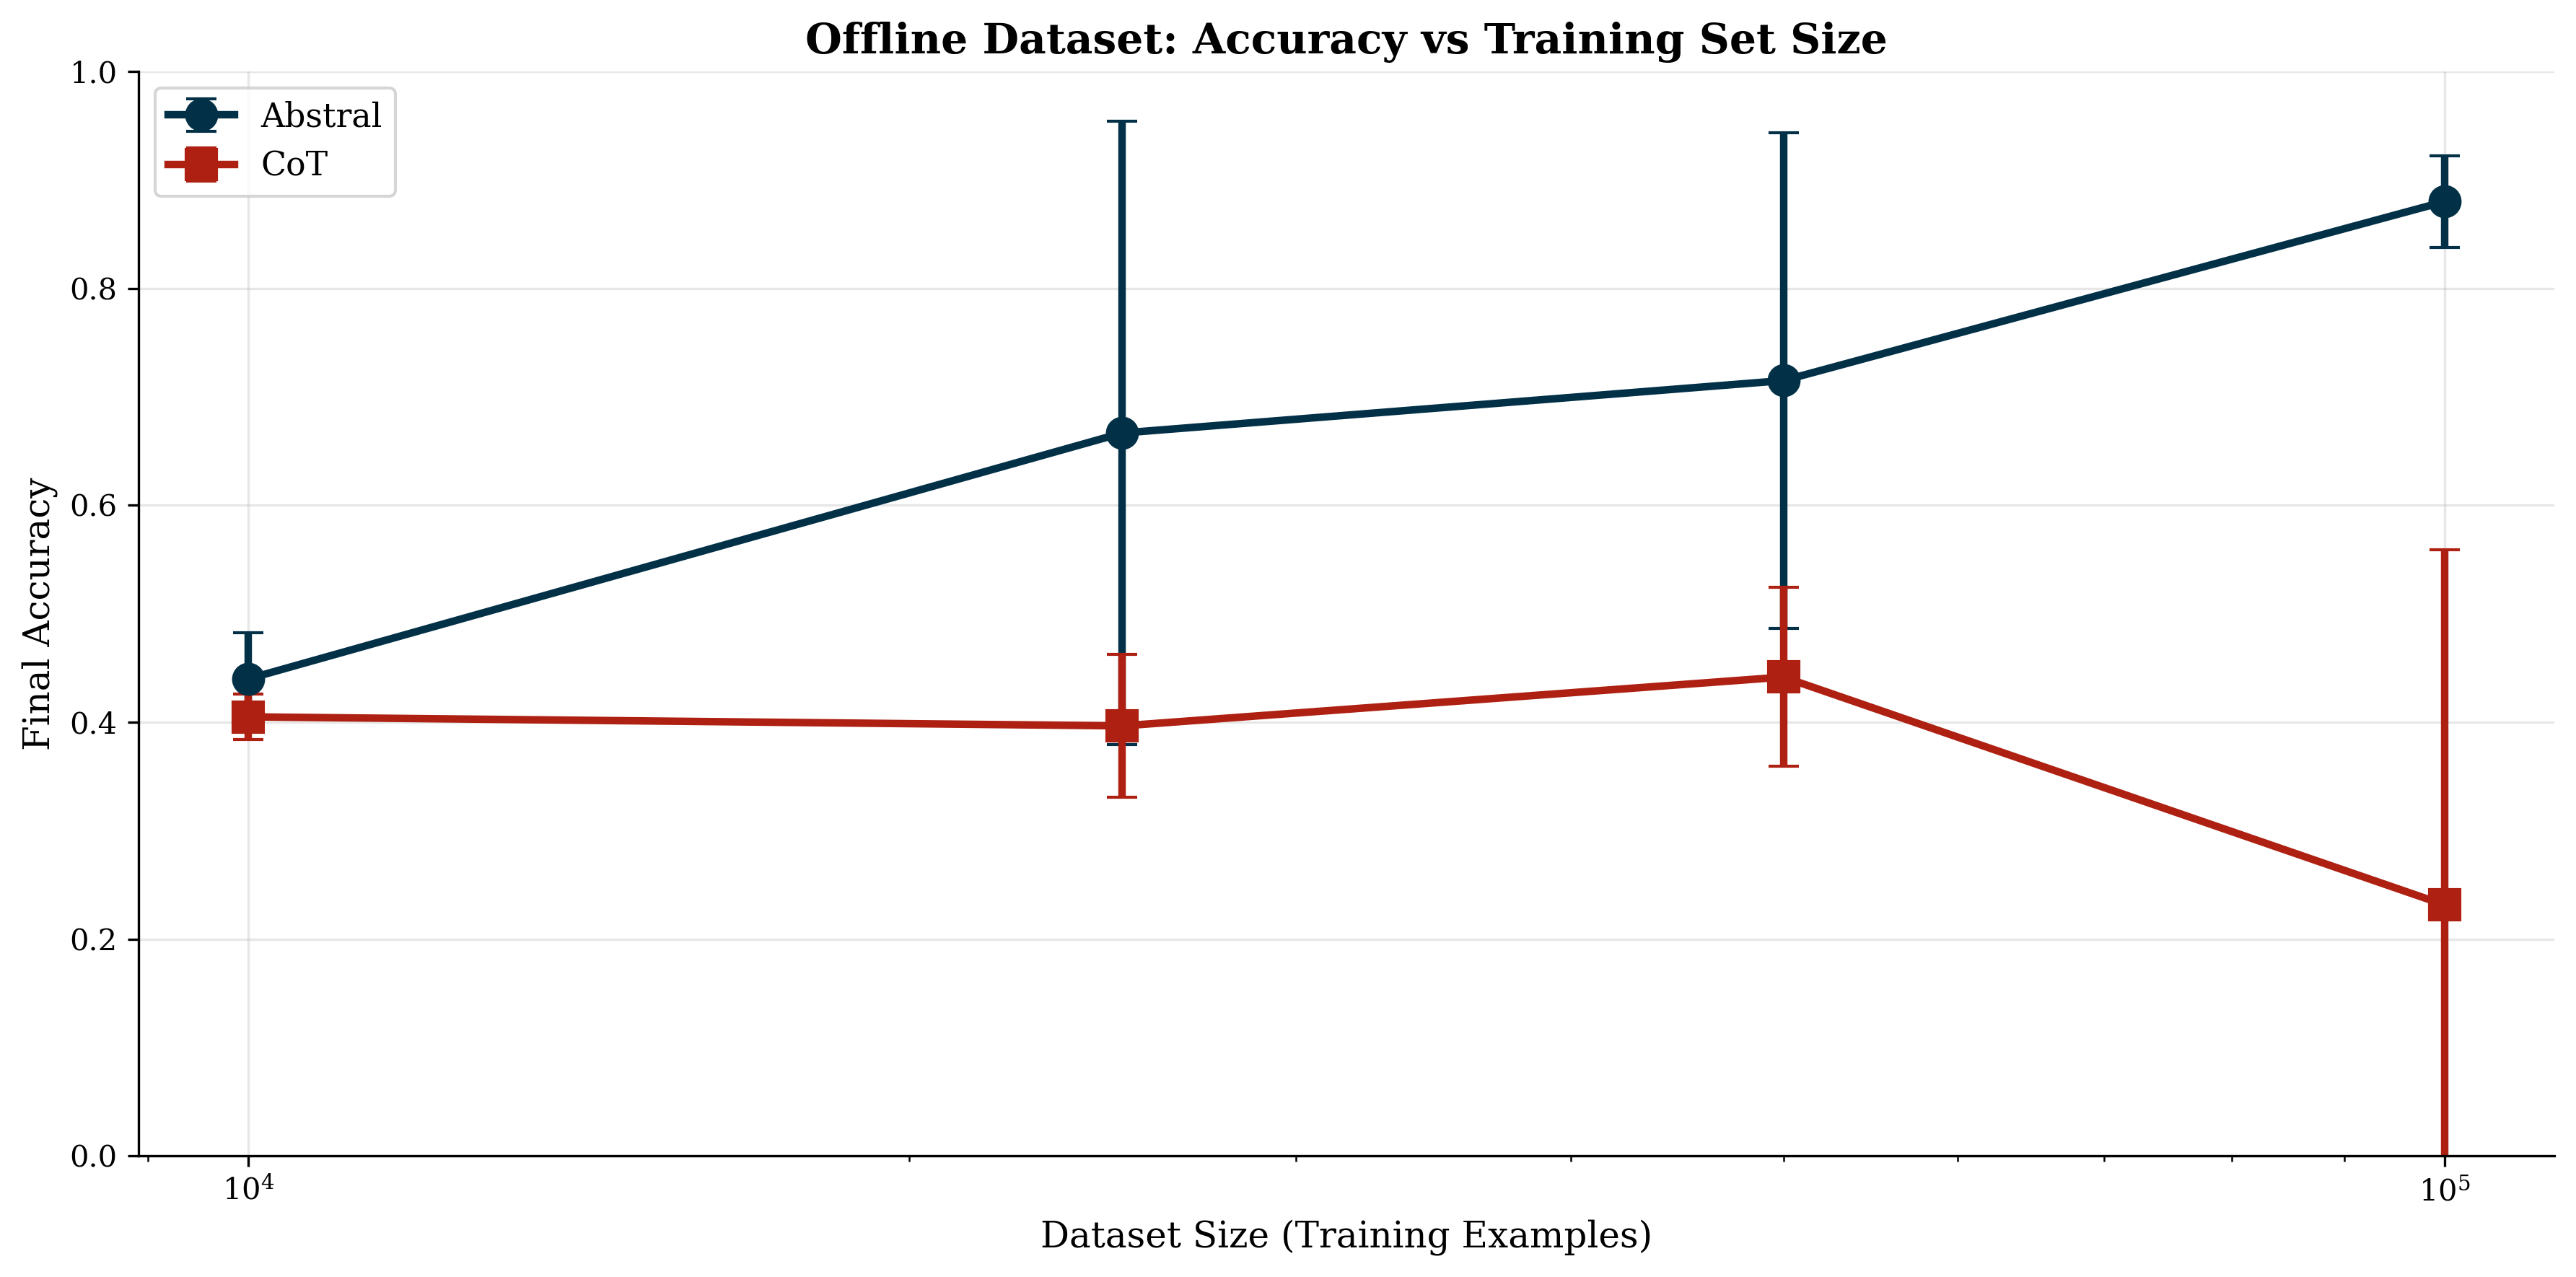


Offline Dataset Summary by Size:
                              mean       std  count
method_type dataset_size                           
Abstral     10000         0.440000  0.042426      2
            25000         0.666667  0.287557      2
            50000         0.715000  0.228631      2
            100000        0.880000  0.042426      2
CoT         10000         0.405000  0.021213      2
            25000         0.396667  0.065997      2
            50000         0.441667  0.082496      2
            100000        0.231667  0.327626      2


In [9]:
# =============================================================================
# OFFLINE DATASET PLOTS
# =============================================================================

# Plot 4: Final accuracy vs dataset size (grouped by method)
fig, ax = plt.subplots(figsize=(12, 6))

# Get unique dataset sizes
if len(df_offline) > 0:
    dataset_sizes = sorted(df_offline['dataset_size'].dropna().unique())
    
    # Group by method type and dataset size (using color_maps colors)
    for method, color in [('Abstral', COLORS['abstral']), ('CoT', COLORS['cot'])]:
        method_data = df_offline[df_offline['method_type'] == method]
        if len(method_data) > 0:
            grouped = method_data.groupby('dataset_size')['final_acc'].agg(['mean', 'std']).reset_index()
            ax.errorbar(
                grouped['dataset_size'], 
                grouped['mean'],
                yerr=grouped['std'],
                marker='o' if method == 'Abstral' else 's',
                markersize=10,
                capsize=5,
                color=color,
                linewidth=2.5,
                label=method
            )
    
    ax.set_xlabel('Dataset Size (Training Examples)', fontsize=12)
    ax.set_ylabel('Final Accuracy', fontsize=12)
    ax.set_title('Offline Dataset: Accuracy vs Training Set Size', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.set_xscale('log')
    ax.set_ylim(0, 1.0)
    
    # Add gridlines
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_plot(fig, 'offline_accuracy_vs_size')
    plt.show()
    
    print("\nOffline Dataset Summary by Size:")
    print(df_offline.groupby(['method_type', 'dataset_size'])['final_acc'].agg(['mean', 'std', 'count']))
else:
    print("No offline runs found")

Saved: results/offline_detailed_breakdown.png and results/offline_detailed_breakdown.pdf


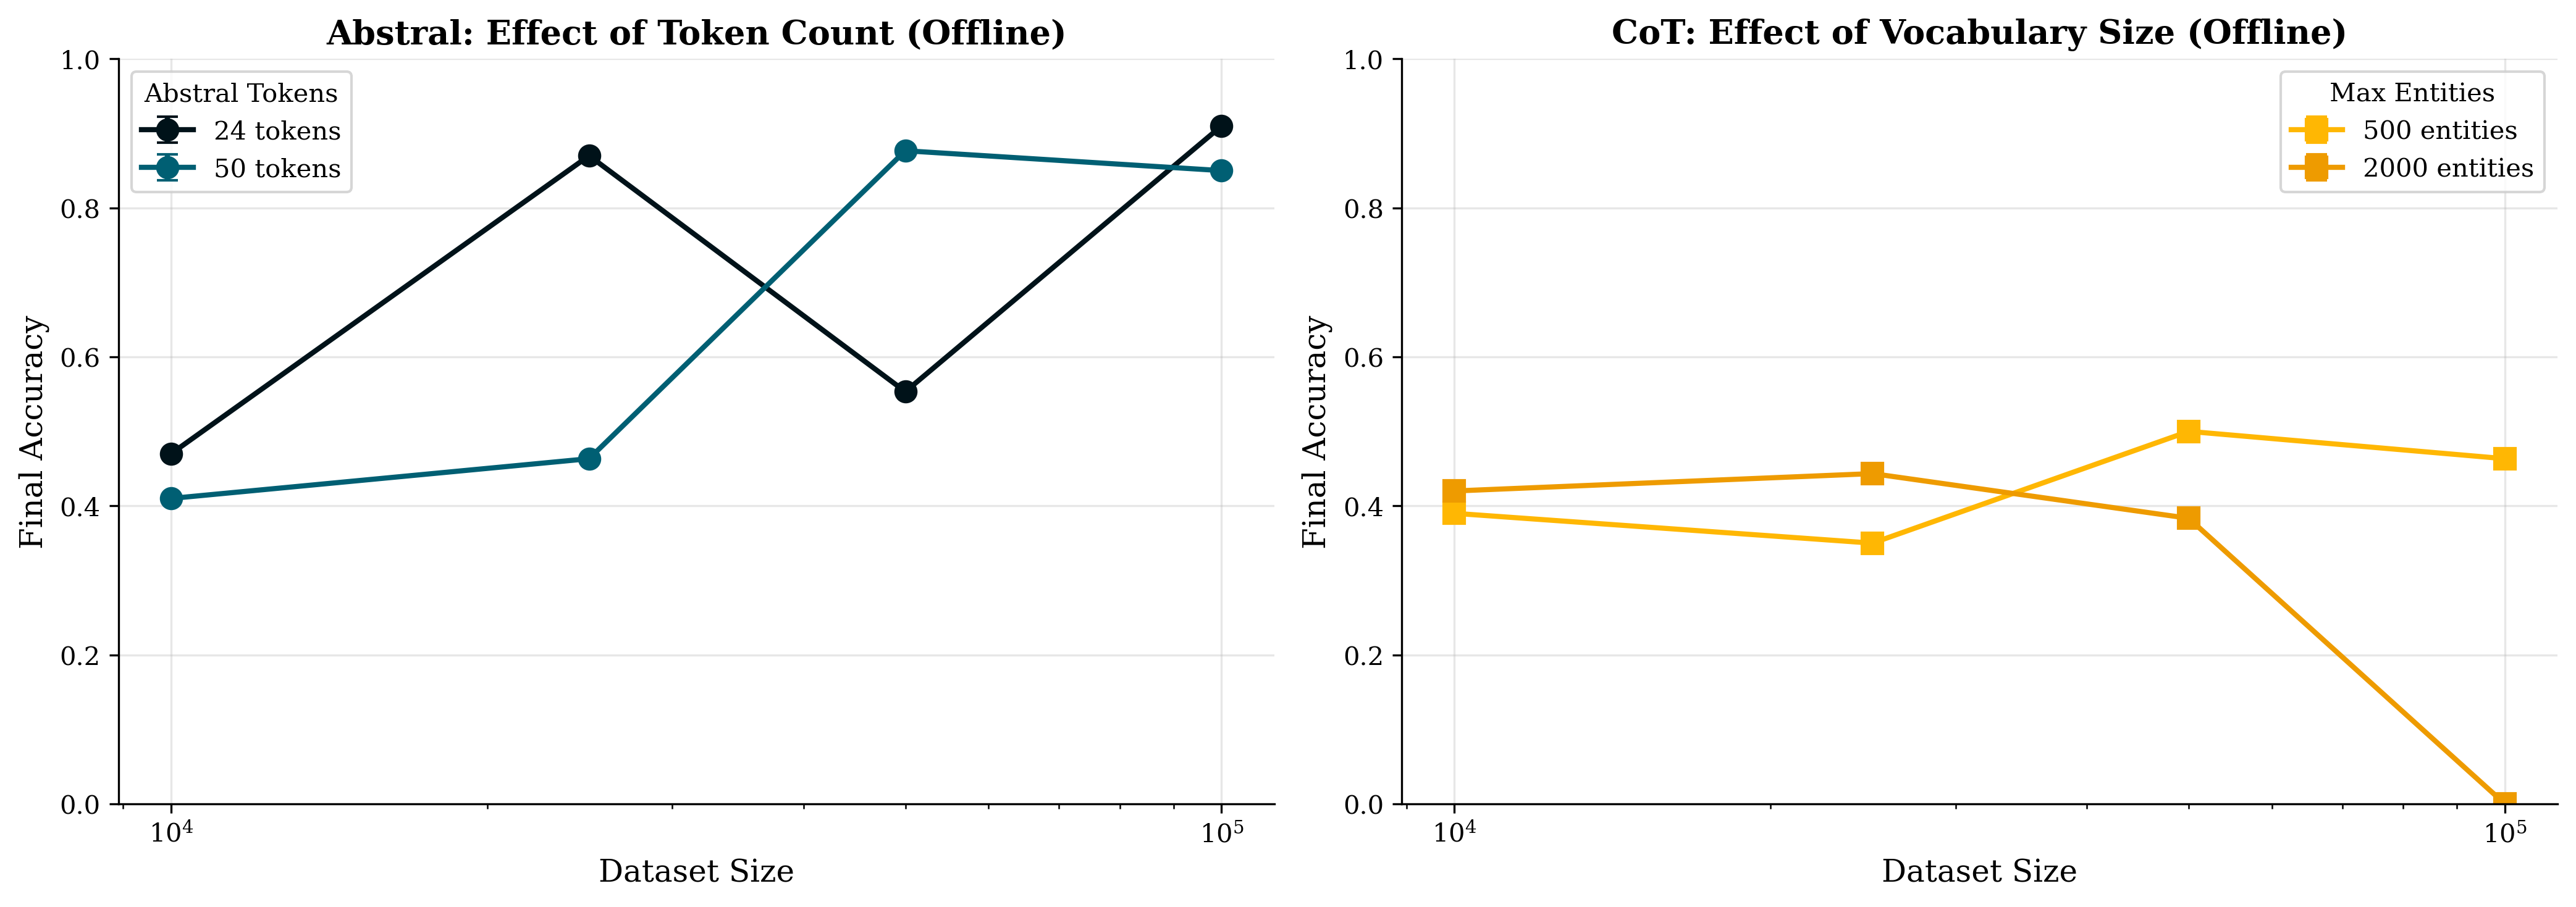

In [10]:
# Plot 2: Detailed breakdown for offline dataset - separate plots for Abstral and CoT

if len(df_offline) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot: Abstral with different n_abstral_tokens across dataset sizes
    df_offline_abstral = df_offline[df_offline['abstral'] == True]
    if len(df_offline_abstral) > 0:
        ax = axes[0]
        tokens = sorted(df_offline_abstral['n_abstral_tokens'].dropna().unique())
        # Use ABSTRAL_GRADIENT colors
        for i, tok in enumerate(tokens):
            tok_data = df_offline_abstral[df_offline_abstral['n_abstral_tokens'] == tok]
            grouped = tok_data.groupby('dataset_size')['final_acc'].agg(['mean', 'std']).reset_index()
            color = ABSTRAL_GRADIENT[i % len(ABSTRAL_GRADIENT)]
            ax.errorbar(
                grouped['dataset_size'], 
                grouped['mean'],
                yerr=grouped['std'],
                marker='o',
                markersize=8,
                capsize=4,
                color=color,
                linewidth=2,
                label=f'{int(tok)} tokens'
            )
        ax.set_xlabel('Dataset Size', fontsize=12)
        ax.set_ylabel('Final Accuracy', fontsize=12)
        ax.set_title('Abstral: Effect of Token Count (Offline)', fontsize=13, fontweight='bold')
        ax.legend(title='Abstral Tokens')
        ax.set_xscale('log')
        ax.set_ylim(0, 1.0)
    
    # Plot: CoT with different max_entities across dataset sizes  
    df_offline_cot = df_offline[df_offline['abstral'] == False]
    if len(df_offline_cot) > 0:
        ax = axes[1]
        entities = sorted(df_offline_cot['max_entities'].dropna().unique())
        # Use COT_GRADIENT colors
        for i, ent in enumerate(entities):
            ent_data = df_offline_cot[df_offline_cot['max_entities'] == ent]
            grouped = ent_data.groupby('dataset_size')['final_acc'].agg(['mean', 'std']).reset_index()
            color = COT_GRADIENT[i % len(COT_GRADIENT)]
            ax.errorbar(
                grouped['dataset_size'], 
                grouped['mean'],
                yerr=grouped['std'],
                marker='s',
                markersize=8,
                capsize=4,
                color=color,
                linewidth=2,
                label=f'{int(ent)} entities'
            )
        ax.set_xlabel('Dataset Size', fontsize=12)
        ax.set_ylabel('Final Accuracy', fontsize=12)
        ax.set_title('CoT: Effect of Vocabulary Size (Offline)', fontsize=13, fontweight='bold')
        ax.legend(title='Max Entities')
        ax.set_xscale('log')
        ax.set_ylim(0, 1.0)
    
    plt.tight_layout()
    save_plot(fig, 'offline_detailed_breakdown')
    plt.show()
else:
    print("No offline runs found")

Saved: results/offline_heatmap.png and results/offline_heatmap.pdf


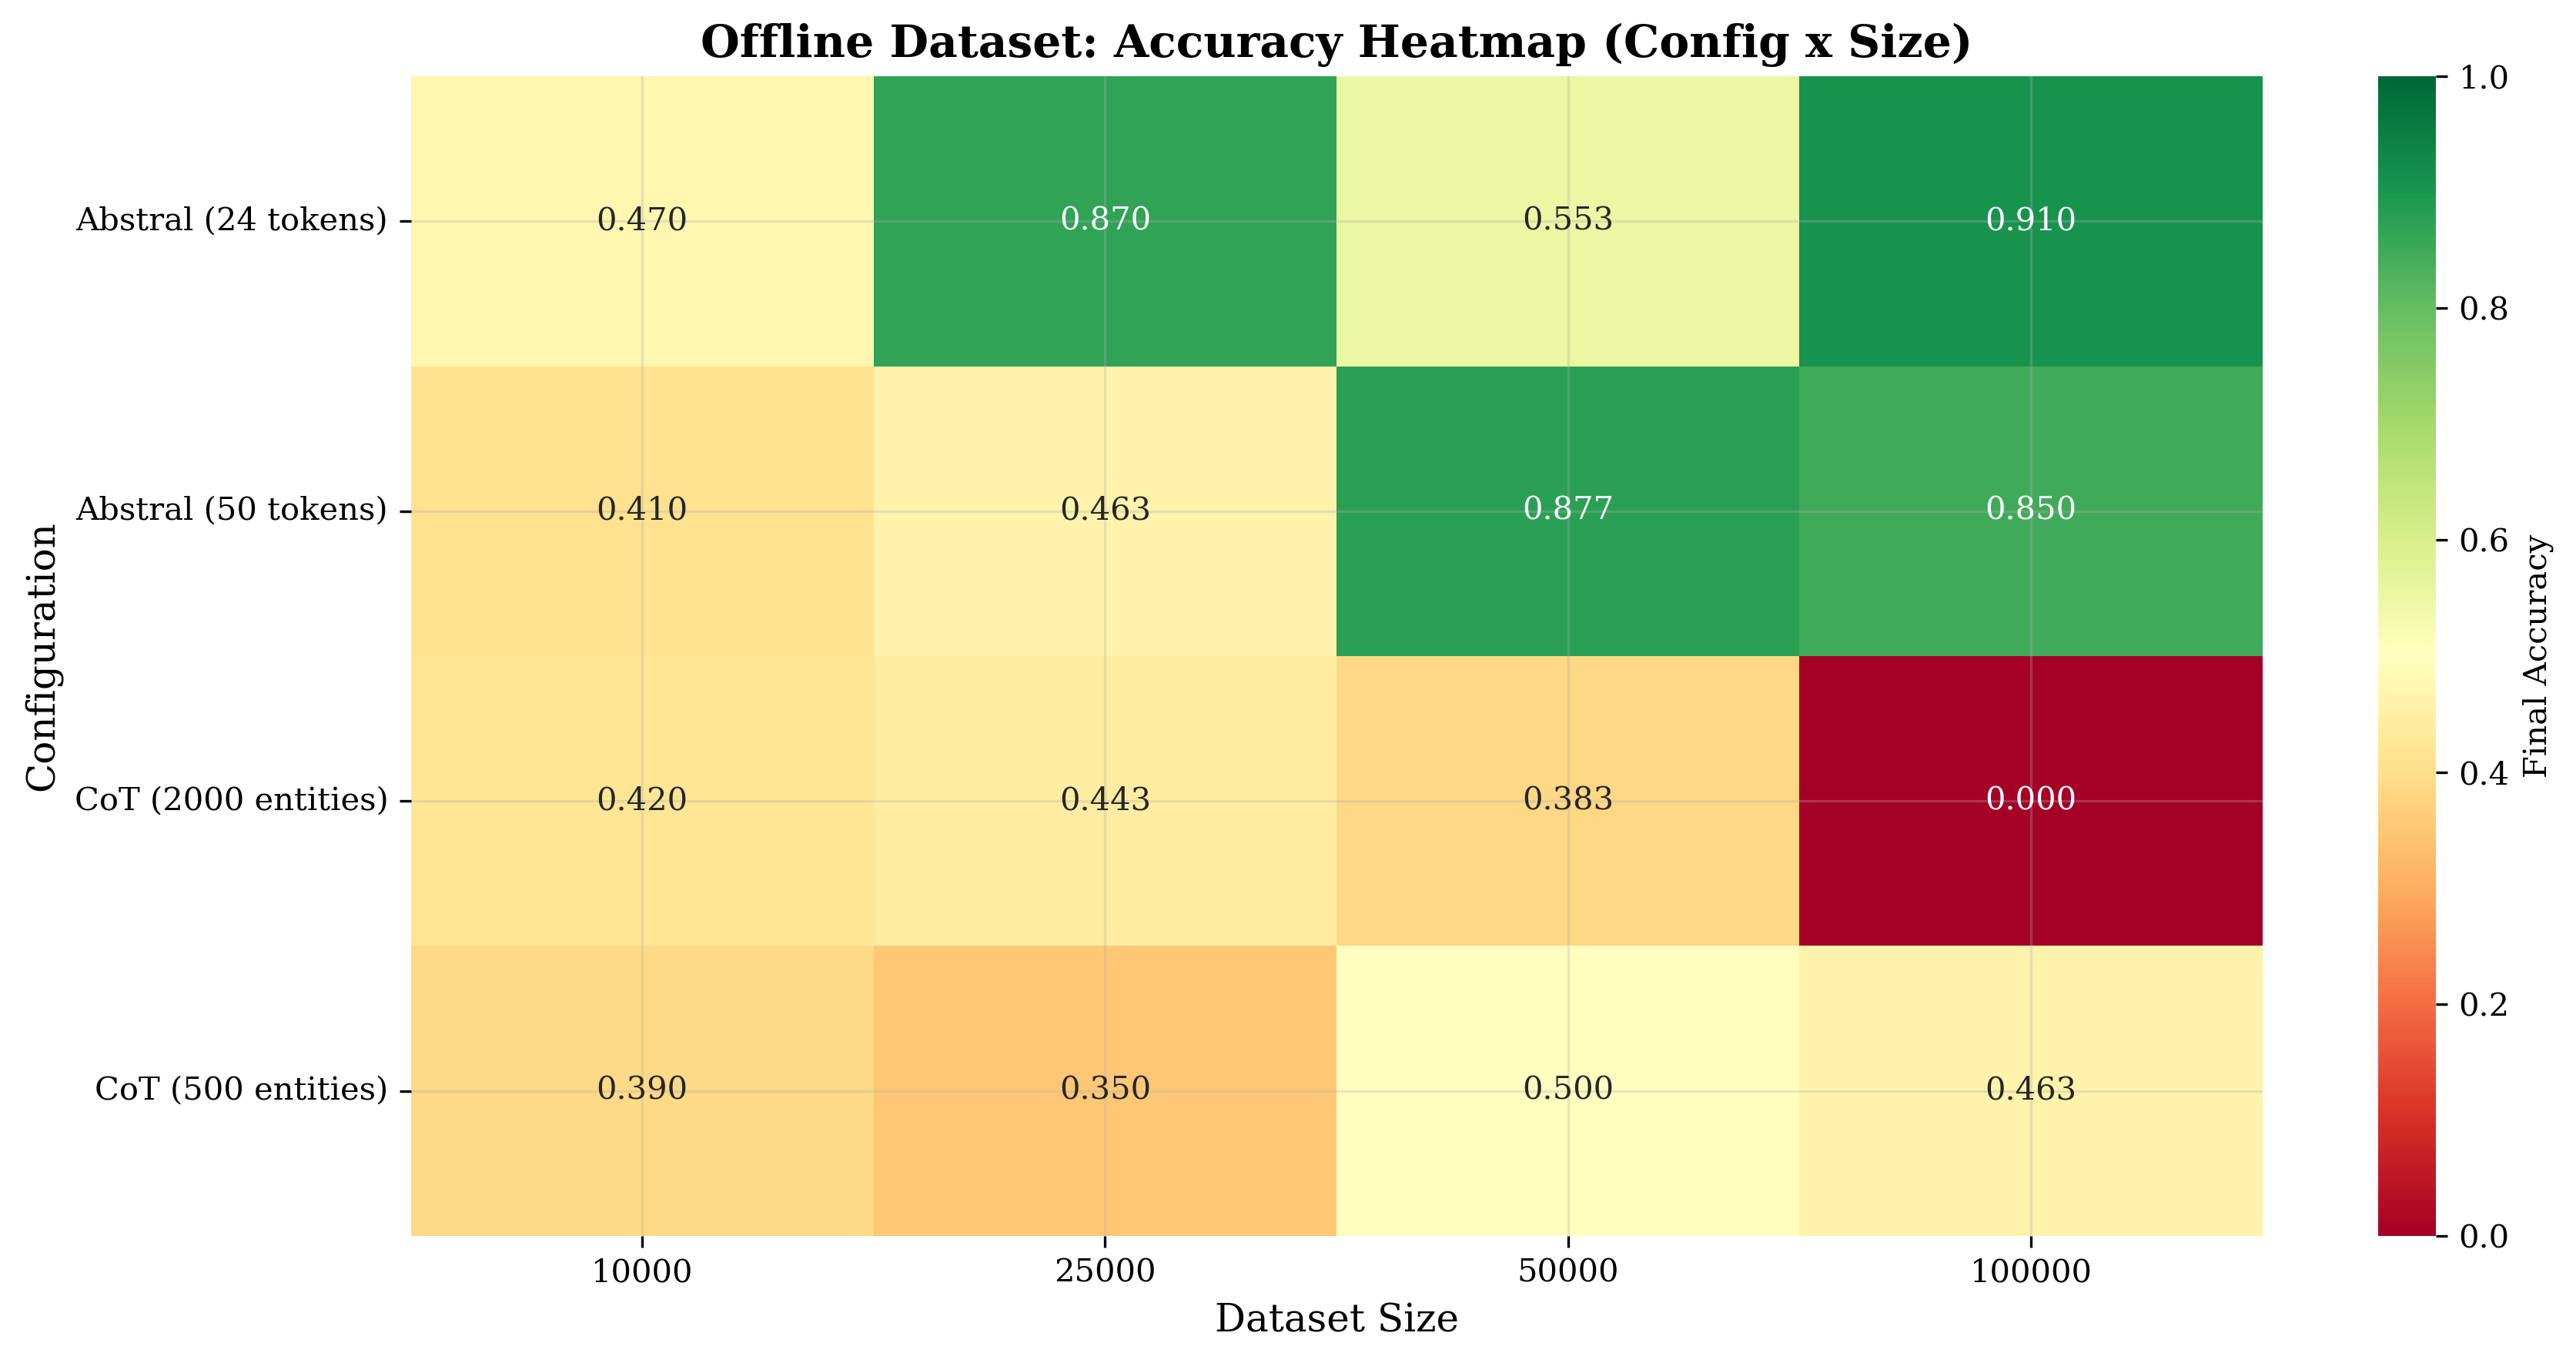

In [11]:
# Plot 6: Heatmap of accuracy for offline dataset (configuration x dataset size)

if len(df_offline) > 0:
    # Pivot table for heatmap
    pivot_data = df_offline.pivot_table(
        values='final_acc', 
        index='label', 
        columns='dataset_size', 
        aggfunc='mean'
    )
    
    if len(pivot_data) > 0:
        fig, ax = plt.subplots(figsize=(12, max(6, len(pivot_data) * 0.5)))
        
        # Create heatmap
        sns.heatmap(
            pivot_data, 
            annot=True, 
            fmt='.3f', 
            cmap='RdYlGn',
            vmin=0, 
            vmax=1,
            ax=ax,
            cbar_kws={'label': 'Final Accuracy'}
        )
        
        ax.set_xlabel('Dataset Size', fontsize=12)
        ax.set_ylabel('Configuration', fontsize=12)
        ax.set_title('Offline Dataset: Accuracy Heatmap (Config x Size)', fontsize=14, fontweight='bold')
        
        plt.tight_layout()
        save_plot(fig, 'offline_heatmap')
        plt.show()
else:
    print("No offline data for heatmap")

Saved: results/summary_comparison.png and results/summary_comparison.pdf


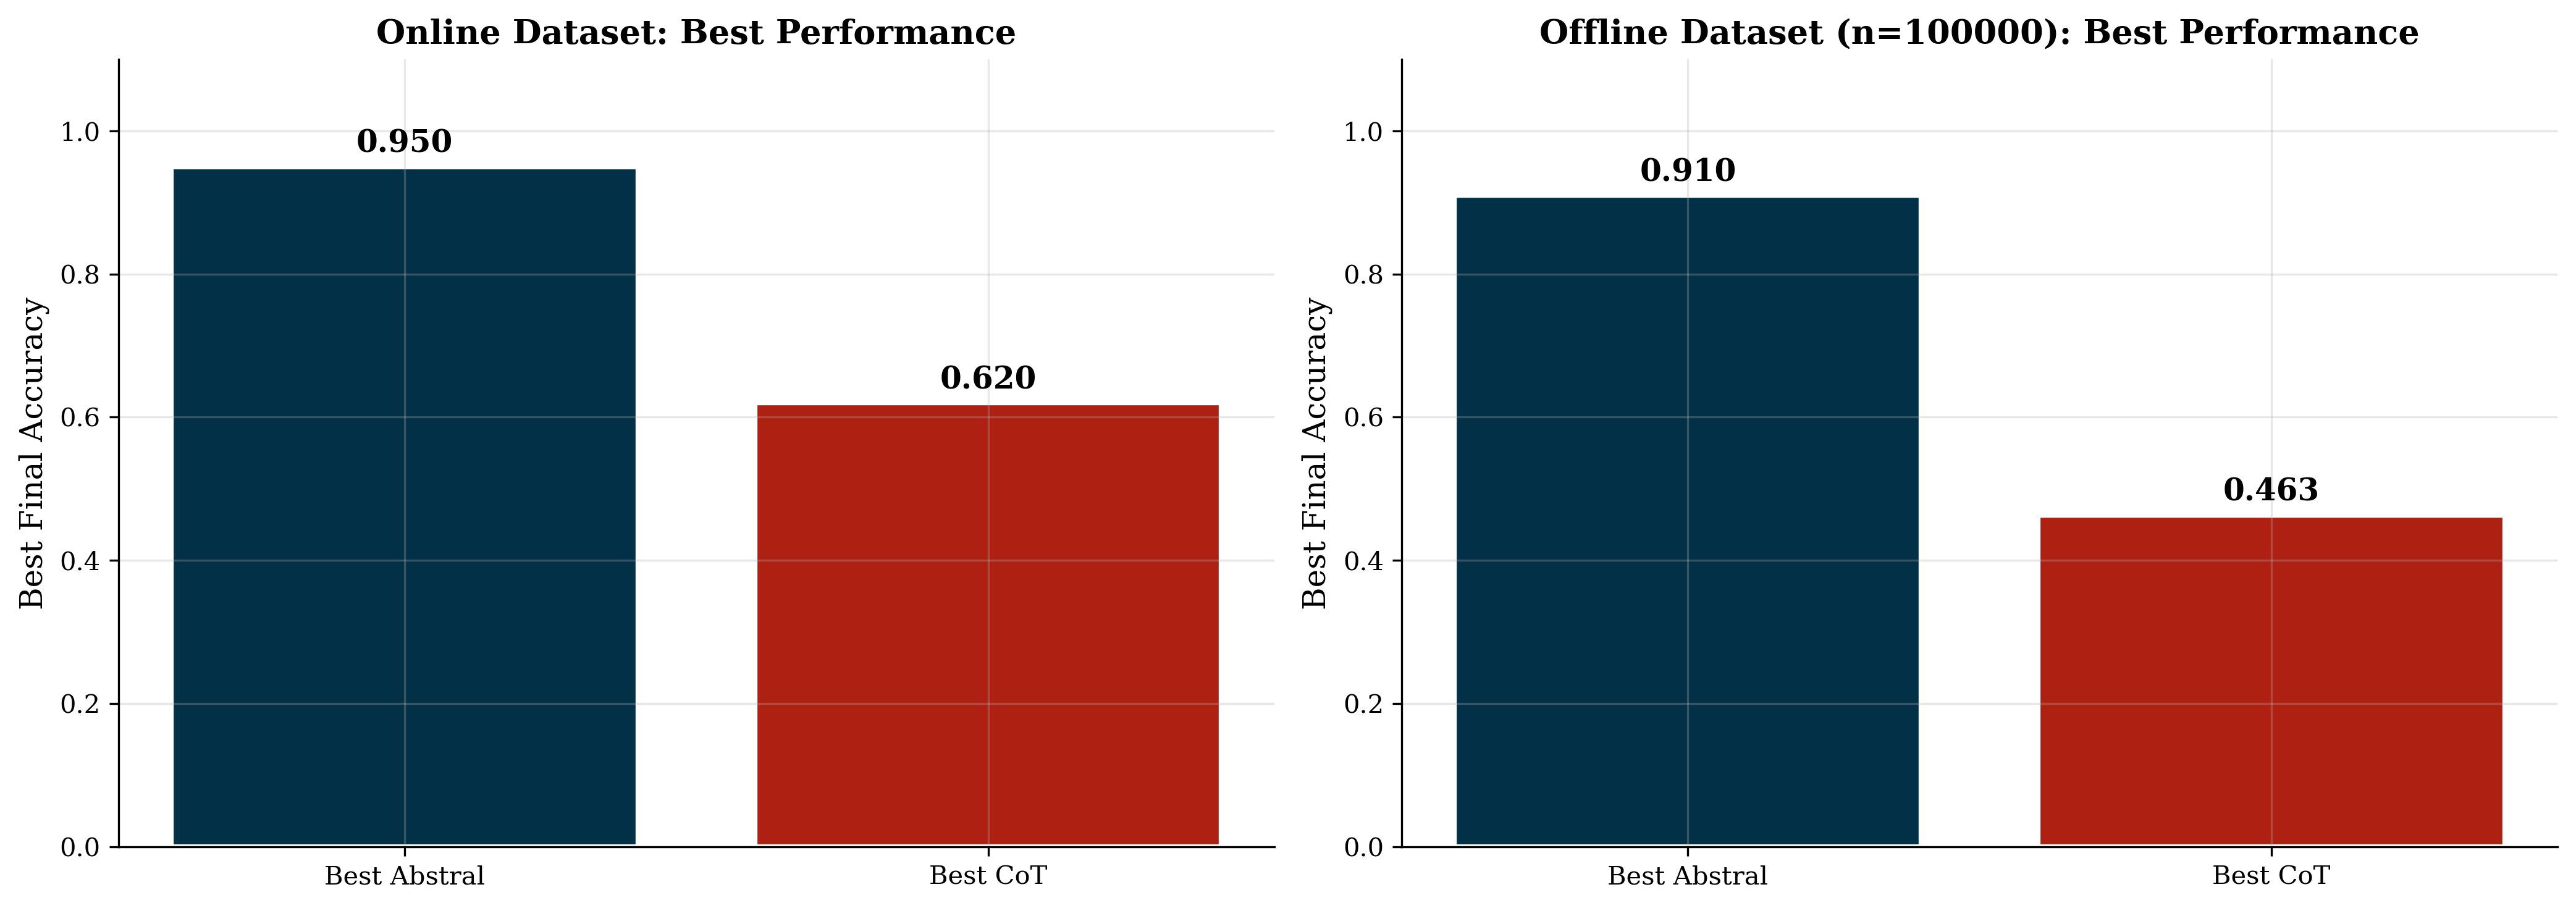

In [12]:
# =============================================================================
# SUMMARY COMPARISON PLOTS
# =============================================================================

# Plot 7: Side-by-side comparison of best Abstral vs best CoT
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Online comparison
ax = axes[0]
if len(df_online) > 0:
    # Best Abstral and best CoT for online
    best_abstral_online = df_online[df_online['abstral'] == True]['final_acc'].max()
    best_cot_online = df_online[df_online['abstral'] == False]['final_acc'].max()
    
    bars = ax.bar(
        ['Best Abstral', 'Best CoT'],
        [best_abstral_online, best_cot_online],
        color=[COLORS['abstral'], COLORS['cot']],
        edgecolor='white',
        linewidth=2
    )
    
    # Add value labels
    for bar, val in zip(bars, [best_abstral_online, best_cot_online]):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
                    f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Best Final Accuracy', fontsize=12)
    ax.set_title('Online Dataset: Best Performance', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
else:
    ax.text(0.5, 0.5, 'No online data', ha='center', va='center', transform=ax.transAxes)

# Offline comparison (at largest dataset size)
ax = axes[1]
if len(df_offline) > 0:
    largest_size = df_offline['dataset_size'].max()
    df_offline_largest = df_offline[df_offline['dataset_size'] == largest_size]
    
    best_abstral_offline = df_offline_largest[df_offline_largest['abstral'] == True]['final_acc'].max()
    best_cot_offline = df_offline_largest[df_offline_largest['abstral'] == False]['final_acc'].max()
    
    bars = ax.bar(
        ['Best Abstral', 'Best CoT'],
        [best_abstral_offline, best_cot_offline],
        color=[COLORS['abstral'], COLORS['cot']],
        edgecolor='white',
        linewidth=2
    )
    
    # Add value labels
    for bar, val in zip(bars, [best_abstral_offline, best_cot_offline]):
        if pd.notna(val):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, 
                    f'{val:.3f}', ha='center', fontsize=12, fontweight='bold')
    
    ax.set_ylabel('Best Final Accuracy', fontsize=12)
    ax.set_title(f'Offline Dataset (n={int(largest_size)}): Best Performance', fontsize=13, fontweight='bold')
    ax.set_ylim(0, 1.1)
else:
    ax.text(0.5, 0.5, 'No offline data', ha='center', va='center', transform=ax.transAxes)

plt.tight_layout()
save_plot(fig, 'summary_comparison')
plt.show()

In [13]:
# Summary Statistics Table

print("=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# Online summary
print("\n--- ONLINE DATASET ---")
if len(df_online) > 0:
    print("\nAbstral configurations:")
    abstral_summary = df_online[df_online['abstral'] == True].groupby('n_abstral_tokens')['final_acc'].agg(['mean', 'std', 'max', 'count'])
    print(abstral_summary.to_string())
    
    print("\nCoT configurations:")
    cot_summary = df_online[df_online['abstral'] == False].groupby('max_entities')['final_acc'].agg(['mean', 'std', 'max', 'count'])
    print(cot_summary.to_string())
    
    print(f"\nBest Abstral accuracy: {df_online[df_online['abstral'] == True]['final_acc'].max():.4f}")
    print(f"Best CoT accuracy: {df_online[df_online['abstral'] == False]['final_acc'].max():.4f}")
else:
    print("No online data available")

# Offline summary
print("\n--- OFFLINE DATASET ---")
if len(df_offline) > 0:
    print("\nAbstral configurations by dataset size:")
    abstral_offline = df_offline[df_offline['abstral'] == True]
    if len(abstral_offline) > 0:
        print(abstral_offline.pivot_table(values='final_acc', index='n_abstral_tokens', columns='dataset_size', aggfunc='mean').to_string())
    
    print("\nCoT configurations by dataset size:")
    cot_offline = df_offline[df_offline['abstral'] == False]
    if len(cot_offline) > 0:
        print(cot_offline.pivot_table(values='final_acc', index='max_entities', columns='dataset_size', aggfunc='mean').to_string())
    
    print(f"\nBest Abstral accuracy: {df_offline[df_offline['abstral'] == True]['final_acc'].max():.4f}")
    print(f"Best CoT accuracy: {df_offline[df_offline['abstral'] == False]['final_acc'].max():.4f}")
else:
    print("No offline data available")

print("\n" + "=" * 80)

SUMMARY STATISTICS

--- ONLINE DATASET ---

Abstral configurations:
                      mean  std       max  count
n_abstral_tokens                                
24                0.910000  NaN  0.910000      1
50                0.950000  NaN  0.950000      1
100               0.213333  NaN  0.213333      1
250               0.030000  NaN  0.030000      1
500               0.013333  NaN  0.013333      1

CoT configurations:
                  mean  std       max  count
max_entities                                
500           0.620000  NaN  0.620000      1
1000          0.506667  NaN  0.506667      1
1500          0.503333  NaN  0.503333      1
2500          0.580000  NaN  0.580000      1
5000          0.520000  NaN  0.520000      1

Best Abstral accuracy: 0.9500
Best CoT accuracy: 0.6200

--- OFFLINE DATASET ---

Abstral configurations by dataset size:
dataset_size      10000     25000     50000   100000
n_abstral_tokens                                    
24                  0.47

# Conclusions

## Key Findings

Based on the experiments comparing **Abstral** (abstract token reasoning) vs **Chain-of-Thought (CoT)** on synthetic reasoning tasks:

### Online Dataset Results
- Compare how Abstral with varying numbers of abstract tokens performs against CoT with varying vocabulary sizes (max_entities)
- Look for trends in accuracy as token count / vocabulary size changes

### Offline Dataset Results  
- Examine how both methods scale with training data size (10k → 100k examples)
- Compare sample efficiency: which method achieves good accuracy with less data?
- Analyze whether Abstral or CoT benefits more from additional training data

### Hyperparameter Sensitivity
- **Abstral**: How sensitive is performance to the number of abstract tokens (24, 50, 100, etc.)?
- **CoT**: How sensitive is performance to vocabulary size (max_entities: 500 → 5000)?

## Questions to Answer

1. Does Abstral achieve comparable or better accuracy than CoT?
2. Is Abstral more sample-efficient (achieves same accuracy with less data)?
3. What is the optimal number of abstract tokens for Abstral?
4. How does vocabulary size affect CoT performance?
5. Which method generalizes better?

---
*Note: Re-run this notebook after adding more experiments to update the analysis.*

Exported data to CSV files in results
Saved: results/all_experiments_summary.png and results/all_experiments_summary.pdf


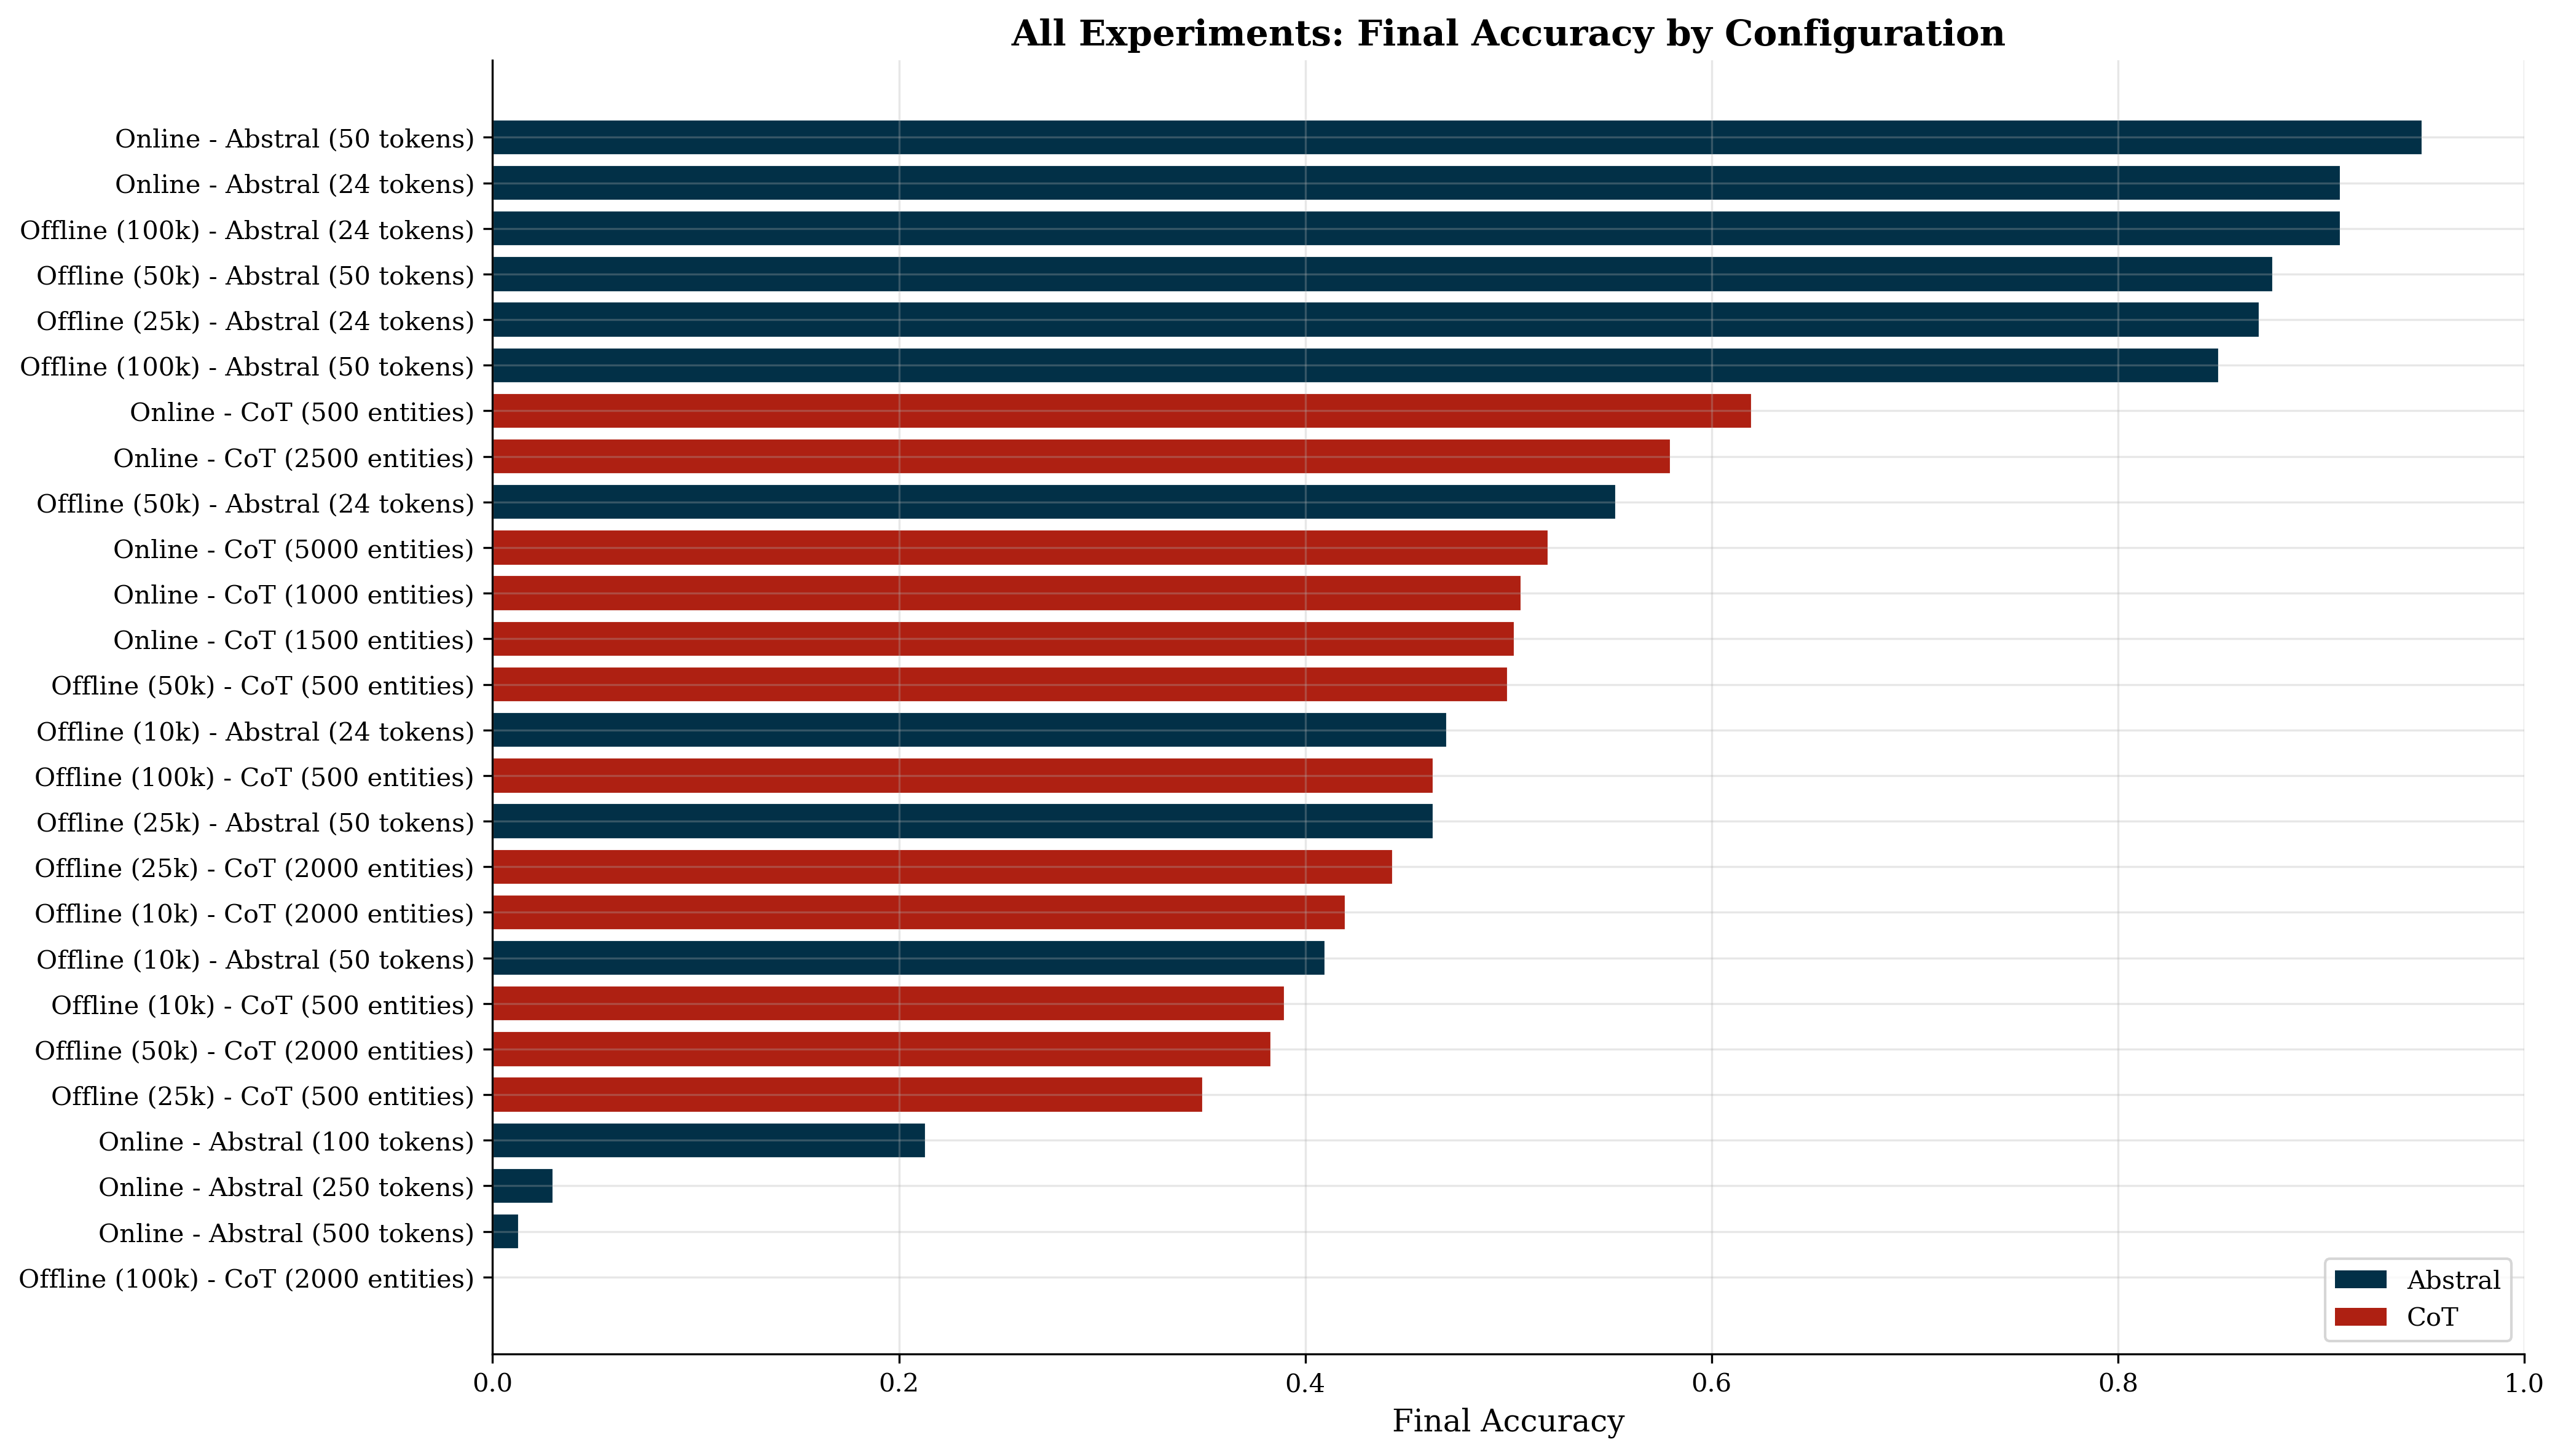


Total experiments analyzed: 26
  - Online: 10
  - Offline: 16


In [14]:
# Additional Analysis: Export data and create combined visualization

# Export data to CSV for further analysis (save to results folder)
df.to_csv(RESULTS_DIR / 'wandb_results_all.csv', index=False)
df_online.to_csv(RESULTS_DIR / 'wandb_results_online.csv', index=False)
df_offline.to_csv(RESULTS_DIR / 'wandb_results_offline.csv', index=False)
print(f"Exported data to CSV files in {RESULTS_DIR}")

# Combined visualization: All configurations
fig, ax = plt.subplots(figsize=(14, 8))

# Combine online and offline data with dataset type indicator
df['dataset_type'] = df['online'].map({True: 'Online', False: 'Offline'})

# Create combined label for visualization
def create_full_label(row):
    base_label = row['label']
    if row['online']:
        return f"Online - {base_label}"
    else:
        size = int(row['dataset_size']) if pd.notna(row['dataset_size']) else 0
        return f"Offline ({size//1000}k) - {base_label}"

df['full_label'] = df.apply(create_full_label, axis=1)

# Group and sort by accuracy
summary_all = df.groupby('full_label')['final_acc'].agg(['mean', 'std']).reset_index()
summary_all = summary_all.sort_values('mean', ascending=True)

# Color based on method type
colors = []
for label in summary_all['full_label']:
    if 'Abstral' in label:
        colors.append(COLORS['abstral'])
    else:
        colors.append(COLORS['cot'])

bars = ax.barh(
    summary_all['full_label'], 
    summary_all['mean'],
    xerr=summary_all['std'],
    color=colors,
    capsize=3,
    edgecolor='white',
    linewidth=1
)

ax.set_xlabel('Final Accuracy', fontsize=12)
ax.set_title('All Experiments: Final Accuracy by Configuration', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.0)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLORS['abstral'], label='Abstral'),
    Patch(facecolor=COLORS['cot'], label='CoT')
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
save_plot(fig, 'all_experiments_summary')
plt.show()

print(f"\nTotal experiments analyzed: {len(df)}")
print(f"  - Online: {len(df_online)}")
print(f"  - Offline: {len(df_offline)}")

# Reasoning Depth Analysis

This section evaluates how trained models perform at different reasoning depths (number of reasoning hops).
We test depths 1-10, where training was done on depths 1-5, to assess generalization beyond the training distribution.

**Key Questions:**
1. Do models generalize to depths beyond training (6-10)?
2. Does Abstral maintain performance better than CoT at higher depths?
3. What is the optimal configuration for depth generalization?

In [15]:
# =============================================================================
# REASONING DEPTH ANALYSIS - Setup
# =============================================================================

import sys
import os
import torch
import yaml
from pathlib import Path
from glob import glob

# Add parent directory to path for imports
sys.path.insert(0, str(Path.cwd().parent))

# Depths to evaluate (training was on 1-5, testing generalization to 6-10)
DEPTHS = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
TRAINING_DEPTH_RANGE = (1, 5)  # Training used num_layers [1, 5]

# Experiment folder
EXPERIMENT_NAME = "abstral_vs_cot_vocab_new_outsize_fixed_shuffling"
OUTPUTS_ROOT = Path("../outputs/experiments") / EXPERIMENT_NAME

# Number of test samples per depth
N_TEST_SAMPLES = 100

print(f"Depths to evaluate: {DEPTHS}")
print(f"Training depth range: {TRAINING_DEPTH_RANGE}")
print(f"Experiment folder: {OUTPUTS_ROOT}")
print(f"Folder exists: {OUTPUTS_ROOT.exists()}")

Depths to evaluate: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Training depth range: (1, 5)
Experiment folder: ../outputs/experiments/abstral_vs_cot_vocab_new_outsize_fixed_shuffling
Folder exists: True


In [16]:
# =============================================================================
# Find Model Checkpoints
# =============================================================================

def find_latest_checkpoint(signature_path):
    """Find the latest checkpoint in a run's folder."""
    # Look for attempt folders (they have random IDs)
    attempt_folders = [d for d in signature_path.iterdir() if d.is_dir()]
    
    latest_checkpoint = None
    latest_epoch = -1
    config_path = None
    
    for attempt_folder in attempt_folders:
        # Find all checkpoints in this attempt
        checkpoints = list(attempt_folder.glob("checkpoint_*"))
        for ckpt in checkpoints:
            # Extract epoch number from checkpoint name
            try:
                epoch = int(ckpt.name.split("_")[1])
                if epoch > latest_epoch:
                    latest_epoch = epoch
                    latest_checkpoint = ckpt
                    # Look for config file
                    cfg = attempt_folder / "config.yaml"
                    if cfg.exists():
                        config_path = cfg
            except (ValueError, IndexError):
                continue
    
    return latest_checkpoint, config_path, latest_epoch

# Map wandb runs to checkpoint paths
checkpoint_info = []

for idx, row in df.iterrows():
    run_id = row['run_id']
    
    # The run_id in wandb is the experiment_signature
    signature_path = OUTPUTS_ROOT / run_id
    
    if signature_path.exists():
        checkpoint_path, config_path, epoch = find_latest_checkpoint(signature_path)
        
        if checkpoint_path:
            checkpoint_info.append({
                'run_id': run_id,
                'label': row['label'],
                'abstral': row['abstral'],
                'n_abstral_tokens': row['n_abstral_tokens'],
                'max_entities': row['max_entities'],
                'online': row['online'],
                'dataset_size': row['dataset_size'],
                'checkpoint_path': str(checkpoint_path),
                'config_path': str(config_path) if config_path else None,
                'checkpoint_epoch': epoch,
                'final_acc': row['final_acc']
            })

df_checkpoints = pd.DataFrame(checkpoint_info)
print(f"Found {len(df_checkpoints)} checkpoints")

# Show found checkpoints
if len(df_checkpoints) > 0:
    print("\nCheckpoints found:")
    print(df_checkpoints[['label', 'online', 'checkpoint_epoch', 'final_acc']].to_string())
else:
    print("No checkpoints found!")

Found 26 checkpoints

Checkpoints found:
                   label  online  checkpoint_epoch  final_acc
0     CoT (500 entities)    True               448   0.620000
1    CoT (2500 entities)    True               485   0.580000
2    Abstral (50 tokens)    True               449   0.950000
3   Abstral (100 tokens)    True               465   0.213333
4   Abstral (250 tokens)    True               475   0.030000
5    CoT (1500 entities)    True               482   0.503333
6    Abstral (24 tokens)    True               451   0.910000
7    CoT (5000 entities)    True               448   0.520000
8   Abstral (500 tokens)    True               496   0.013333
9    CoT (1000 entities)    True               355   0.506667
10    CoT (500 entities)   False               498   0.500000
11    CoT (500 entities)   False               500   0.390000
12    CoT (500 entities)   False               500   0.350000
13    CoT (500 entities)   False               268   0.463333
14   Abstral (24 tokens)   Fa

In [17]:
# =============================================================================
# Evaluation Function for Specific Reasoning Depth
# =============================================================================

import tempfile
import json as json_module
import re
from transformers import AutoTokenizer, GPT2LMHeadModel, GPT2Config
from torch.utils.data import DataLoader
from tqdm import tqdm

# Import from the project
try:
    from dataset import get_dataset, generate_dataset, MyCollator
    from model import Coconut
    from preprocessing.prosqa import DAG
    from abstral import deabstral_text
    print("Successfully imported project modules")
except ImportError as e:
    print(f"Import error: {e}")
    print("Make sure you're running from the notebooks directory")

# Load names and entities lists
NAMES_FILE = Path("../data/names.txt")
ENTITIES_FILE = Path("../data/entities.txt")

if NAMES_FILE.exists() and ENTITIES_FILE.exists():
    with open(NAMES_FILE) as f:
        NAMES_LIST = [line.strip() for line in f if line.strip()]
    with open(ENTITIES_FILE) as f:
        ENTITIES_LIST = [line.strip() for line in f if line.strip()]
    print(f"Loaded {len(NAMES_LIST)} names and {len(ENTITIES_LIST)} entities")
else:
    print(f"Warning: names/entities files not found at {NAMES_FILE} and {ENTITIES_FILE}")
    NAMES_LIST = []
    ENTITIES_LIST = []

def load_config(config_path):
    """Load config from YAML file."""
    with open(config_path, 'r') as f:
        return yaml.safe_load(f)

def simple_evaluate(model, tokenizer, test_data, device, abstral=False, max_new_tokens=256):
    """
    Simple evaluation: generate answers and check accuracy.
    
    Args:
        model: The model to evaluate
        tokenizer: Tokenizer
        test_data: List of dicts with 'question' and 'answer' keys
        device: Device to use
        abstral: Whether this is an abstral model
        max_new_tokens: Max tokens to generate
        
    Returns:
        dict with accuracy metrics
    """
    model.eval()
    correct = 0
    total = 0
    
    for sample in tqdm(test_data, desc="Evaluating"):
        question = sample['question']
        expected_answer = sample['answer'].replace(",", "").strip()
        
        # Tokenize input
        input_text = question + "\n"
        input_ids = tokenizer.encode(input_text, return_tensors='pt').to(device)
        
        # Generate
        with torch.no_grad():
            outputs = model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,
                do_sample=False,  # Greedy decoding
                pad_token_id=tokenizer.eos_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        
        # Decode output
        generated = tokenizer.decode(outputs[0], skip_special_tokens=False)
        
        # Handle abstral tokens
        if abstral:
            generated = deabstral_text(generated)
        
        # Extract answer (look for "### " pattern)
        if "### " in generated:
            pred_answer = generated.split("### ")[-1].split("\n")[0].strip()
        else:
            pred_answer = generated.split("\n")[-1].strip()
        
        # Check if correct
        if pred_answer.lower() == expected_answer.lower():
            correct += 1
        total += 1
    
    return {
        'correct': correct,
        'total': total,
        'accuracy': correct / max(total, 1)
    }

def evaluate_model_at_depth(checkpoint_path, config_path, depth, n_samples=100, device='cuda'):
    """
    Evaluate a model checkpoint at a specific reasoning depth.
    
    Args:
        checkpoint_path: Path to model checkpoint
        config_path: Path to config YAML
        depth: Reasoning depth to evaluate (number of reasoning hops)
        n_samples: Number of test samples
        device: Device to use for evaluation
        
    Returns:
        dict with accuracy metrics
    """
    # Load config
    config = load_config(config_path)
    dataset_cfg = config.get('dataset', {})
    
    # Load tokenizer
    tokenizer_path = config.get('tokenizer_path', None)
    if tokenizer_path and os.path.exists(tokenizer_path):
        tokenizer = AutoTokenizer.from_pretrained(tokenizer_path)
    else:
        tokenizer = AutoTokenizer.from_pretrained('gpt2')
    
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    
    # Determine model type
    is_abstral = config.get('abstral', False)
    n_abstral_tokens = config.get('n_abstral_tokens', 50)
    
    # Get dataset parameters
    max_names = dataset_cfg.get('max_names', 50)
    max_entities = dataset_cfg.get('max_entities', 500)
    unified = dataset_cfg.get('unified_names_entities', True)
    
    # Use subset of names/entities based on config
    names_subset = NAMES_LIST[:max_names] if NAMES_LIST else [f"name_{i}" for i in range(max_names)]
    entities_subset = ENTITIES_LIST[:max_entities] if ENTITIES_LIST else [f"entity_{i}" for i in range(max_entities)]
    
    # Generate test dataset at specific depth
    with tempfile.NamedTemporaryFile(mode='w', suffix='.json', delete=False) as f:
        temp_path = f.name
    
    try:
        # Generate dataset with specific depth
        generate_dataset(
            path=temp_path,
            size=n_samples,
            method=dataset_cfg.get('method', 'tml'),
            num_nodes=dataset_cfg.get('num_nodes', [16, 24]),
            num_layers=[depth, depth],  # Fix num_layers to specific depth
            num_edges=dataset_cfg.get('num_edges', [30, 50]),
            names_list=names_subset,
            entities_list=entities_subset,
            dist=dataset_cfg.get('dist', 'unif'),
            length=depth,        # Set exact reasoning length
            min_length=depth,    # Min = depth
            max_length=depth,    # Max = depth
            neg_length=0,
            min_neg_length=1,
            max_neg_length=-1,
            num_chains=1,
            max_trials=100,
            unified_names_entities=unified,
        )
        
        # Load raw test data for evaluation
        with open(temp_path, 'r') as f:
            test_data = json_module.load(f)
        
    finally:
        # Clean up temp file
        if os.path.exists(temp_path):
            os.remove(temp_path)
    
    # Load model
    model_overrides = config.get('model_config_overrides', {})
    model_config = GPT2Config(
        vocab_size=len(tokenizer),
        **model_overrides
    )
    
    if config.get('coconut', False):
        # Coconut model
        base_model = GPT2LMHeadModel(model_config)
        latent_id = tokenizer.convert_tokens_to_ids('<|latent|>')
        start_id = tokenizer.convert_tokens_to_ids('<|start-latent|>')
        end_id = tokenizer.convert_tokens_to_ids('<|end-latent|>')
        model = Coconut(base_model, latent_id, start_id, end_id, tokenizer.eos_token_id)
    else:
        model = GPT2LMHeadModel(model_config)
    
    # Load checkpoint weights
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint, strict=False)
    model = model.to(device)
    model.eval()
    
    # Run simple evaluation
    results = simple_evaluate(
        model=model,
        tokenizer=tokenizer,
        test_data=test_data,
        device=device,
        abstral=is_abstral,
        max_new_tokens=256
    )
    
    # Clean up
    del model
    torch.cuda.empty_cache()
    
    return {
        'depth': depth,
        'accuracy': results['accuracy'],
        'accuracy_1': results['accuracy'],  # Same as accuracy for greedy
        'total': results['total']
    }

print("Evaluation function defined")

Import error: cannot import name 'Coconut' from 'model' (/tmlscratch/dngfra/coconut/model.py)
Make sure you're running from the notebooks directory
Loaded 100 names and 1000 entities
Evaluation function defined


In [19]:
# =============================================================================
# Run Depth Evaluation Loop
# =============================================================================

# Select models to evaluate (online models only for this analysis)
# You can filter further if needed
df_to_evaluate = df_checkpoints[df_checkpoints['online'] == False].copy()

print(f"Models to evaluate: {len(df_to_evaluate)}")
print(df_to_evaluate[['label', 'abstral', 'checkpoint_epoch']].to_string())

# Check if CUDA is available
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\nUsing device: {device}")

# Results storage
depth_results = []

# Evaluation loop
for idx, model_row in df_to_evaluate.iterrows():
    model_label = model_row['label']
    checkpoint_path = model_row['checkpoint_path']
    config_path = model_row['config_path']
    
    print(f"\n{'='*60}")
    print(f"Evaluating: {model_label}")
    print(f"Checkpoint: {checkpoint_path}")
    print(f"{'='*60}")
    
    if config_path is None:
        print(f"  Skipping - no config file found")
        continue
    
    for depth in DEPTHS:
        print(f"  Depth {depth}...", end=" ", flush=True)
        
        try:
            result = evaluate_model_at_depth(
                checkpoint_path=checkpoint_path,
                config_path=config_path,
                depth=depth,
                n_samples=N_TEST_SAMPLES,
                device=device
            )
            
            depth_results.append({
                'model_label': model_label,
                'abstral': model_row['abstral'],
                'n_abstral_tokens': model_row['n_abstral_tokens'],
                'max_entities': model_row['max_entities'],
                'online': model_row['online'],
                'depth': depth,
                'accuracy': result['accuracy'],
                'accuracy_1': result['accuracy_1'],
                'total_samples': result['total'],
                'in_training_range': TRAINING_DEPTH_RANGE[0] <= depth <= TRAINING_DEPTH_RANGE[1]
            })
            
            print(f"Acc: {result['accuracy']:.3f}")
            
        except Exception as e:
            print(f"Error: {e}")
            depth_results.append({
                'model_label': model_label,
                'abstral': model_row['abstral'],
                'n_abstral_tokens': model_row['n_abstral_tokens'],
                'max_entities': model_row['max_entities'],
                'online': model_row['online'],
                'depth': depth,
                'accuracy': None,
                'accuracy_1': None,
                'total_samples': 0,
                'in_training_range': TRAINING_DEPTH_RANGE[0] <= depth <= TRAINING_DEPTH_RANGE[1]
            })

# Create results DataFrame
df_depth_results = pd.DataFrame(depth_results)
print(f"\n\nCompleted evaluation. Total results: {len(df_depth_results)}")

Models to evaluate: 16
                  label  abstral  checkpoint_epoch
10   CoT (500 entities)    False               498
11   CoT (500 entities)    False               500
12   CoT (500 entities)    False               500
13   CoT (500 entities)    False               268
14  Abstral (24 tokens)     True               500
15  Abstral (24 tokens)     True               263
16  Abstral (50 tokens)     True               500
17  Abstral (50 tokens)     True               263
18  Abstral (50 tokens)     True               500
19  Abstral (50 tokens)     True               490
20  CoT (2000 entities)    False               484
21  CoT (2000 entities)    False               500
22  CoT (2000 entities)    False               500
23  Abstral (24 tokens)     True               500
24  Abstral (24 tokens)     True               469
25  CoT (2000 entities)    False               239

Using device: cuda

Evaluating: CoT (500 entities)
Checkpoint: ../outputs/experiments/abstral_vs_cot_vocab_ne

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

Acc: 0.000
  Depth 2... Generating dataset with size 100 and outputting to path /tmp/tmpr2vkyj8_.json!
Parameters: num_nodes - [16, 24], num_layers - [2, 2], num_edges - [30, 50], length - 2, min_length - 2, max_length - 2, neg_length - 0, min_neg_length - 1, max_neg_length - -1 - unified_names_entities True



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The

KeyboardInterrupt: 

In [ ]:
# =============================================================================
# Plot Accuracy vs Reasoning Depth
# =============================================================================

if len(df_depth_results) > 0 and df_depth_results['accuracy'].notna().any():
    
    # Plot 1: All models - Accuracy vs Depth
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Separate Abstral and CoT models
    df_abstral_depth = df_depth_results[df_depth_results['abstral'] == True]
    df_cot_depth = df_depth_results[df_depth_results['abstral'] == False]
    
    # Plot Abstral models (varying n_abstral_tokens)
    ax = axes[0]
    if len(df_abstral_depth) > 0:
        tokens_list = sorted(df_abstral_depth['n_abstral_tokens'].dropna().unique())
        for i, tokens in enumerate(tokens_list):
            model_data = df_abstral_depth[df_abstral_depth['n_abstral_tokens'] == tokens]
            grouped = model_data.groupby('depth')['accuracy'].agg(['mean', 'std']).reset_index()
            color = ABSTRAL_GRADIENT[i % len(ABSTRAL_GRADIENT)]
            ax.errorbar(
                grouped['depth'], 
                grouped['mean'],
                yerr=grouped['std'],
                marker='o',
                markersize=8,
                capsize=4,
                color=color,
                linewidth=2,
                label=f'Abstral ({int(tokens)} tokens)'
            )
    
    # Add vertical line for training range boundary
    ax.axvline(x=TRAINING_DEPTH_RANGE[1], color='gray', linestyle='--', alpha=0.5, label='Training range')
    ax.axvspan(TRAINING_DEPTH_RANGE[0], TRAINING_DEPTH_RANGE[1], alpha=0.1, color='green')
    
    ax.set_xlabel('Reasoning Depth (# hops)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Abstral: Accuracy vs Reasoning Depth', fontsize=13, fontweight='bold')
    ax.legend(loc='lower left')
    ax.set_ylim(0, 1.0)
    ax.set_xticks(DEPTHS)
    ax.grid(True, alpha=0.3)
    
    # Plot CoT models (varying max_entities)
    ax = axes[1]
    if len(df_cot_depth) > 0:
        entities_list = sorted(df_cot_depth['max_entities'].dropna().unique())
        for i, entities in enumerate(entities_list):
            model_data = df_cot_depth[df_cot_depth['max_entities'] == entities]
            grouped = model_data.groupby('depth')['accuracy'].agg(['mean', 'std']).reset_index()
            color = COT_GRADIENT[i % len(COT_GRADIENT)]
            ax.errorbar(
                grouped['depth'], 
                grouped['mean'],
                yerr=grouped['std'],
                marker='s',
                markersize=8,
                capsize=4,
                color=color,
                linewidth=2,
                label=f'CoT ({int(entities)} entities)'
            )
    
    # Add vertical line for training range boundary
    ax.axvline(x=TRAINING_DEPTH_RANGE[1], color='gray', linestyle='--', alpha=0.5, label='Training range')
    ax.axvspan(TRAINING_DEPTH_RANGE[0], TRAINING_DEPTH_RANGE[1], alpha=0.1, color='green')
    
    ax.set_xlabel('Reasoning Depth (# hops)', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('CoT: Accuracy vs Reasoning Depth', fontsize=13, fontweight='bold')
    ax.legend(loc='lower left')
    ax.set_ylim(0, 1.0)
    ax.set_xticks(DEPTHS)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_plot(fig, 'depth_analysis_separate')
    plt.show()

else:
    print("No depth evaluation results to plot")

No depth evaluation results to plot


In [ ]:
# =============================================================================
# Plot 2: Abstral vs CoT Comparison at Each Depth
# =============================================================================

if len(df_depth_results) > 0 and df_depth_results['accuracy'].notna().any():
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Compute best performance at each depth for Abstral and CoT
    abstral_by_depth = df_depth_results[df_depth_results['abstral'] == True].groupby('depth')['accuracy'].max()
    cot_by_depth = df_depth_results[df_depth_results['abstral'] == False].groupby('depth')['accuracy'].max()
    
    # Plot comparison
    depths_with_data = sorted(set(abstral_by_depth.index) | set(cot_by_depth.index))
    
    if len(abstral_by_depth) > 0:
        ax.plot(abstral_by_depth.index, abstral_by_depth.values, 
                marker='o', markersize=10, linewidth=2.5, 
                color=COLORS['abstral'], label='Best Abstral')
    
    if len(cot_by_depth) > 0:
        ax.plot(cot_by_depth.index, cot_by_depth.values, 
                marker='s', markersize=10, linewidth=2.5, 
                color=COLORS['cot'], label='Best CoT')
    
    # Add training range shading
    ax.axvspan(TRAINING_DEPTH_RANGE[0], TRAINING_DEPTH_RANGE[1], 
               alpha=0.15, color='green', label='Training range')
    ax.axvline(x=TRAINING_DEPTH_RANGE[1], color='gray', linestyle='--', alpha=0.5)
    
    ax.set_xlabel('Reasoning Depth (# hops)', fontsize=12)
    ax.set_ylabel('Best Accuracy', fontsize=12)
    ax.set_title('Abstral vs CoT: Best Performance at Each Depth', fontsize=14, fontweight='bold')
    ax.legend(loc='lower left')
    ax.set_ylim(0, 1.0)
    ax.set_xticks(DEPTHS)
    ax.grid(True, alpha=0.3)
    
    # Add annotations for out-of-distribution performance
    ax.annotate('In-distribution', xy=(3, 0.95), fontsize=10, color='green', alpha=0.7)
    ax.annotate('Out-of-distribution', xy=(7, 0.95), fontsize=10, color='red', alpha=0.7)
    
    plt.tight_layout()
    save_plot(fig, 'depth_analysis_comparison')
    plt.show()
    
    # Print comparison statistics
    print("\nAccuracy comparison at each depth:")
    comparison_df = pd.DataFrame({
        'Depth': depths_with_data,
        'Best Abstral': [abstral_by_depth.get(d, None) for d in depths_with_data],
        'Best CoT': [cot_by_depth.get(d, None) for d in depths_with_data]
    })
    comparison_df['Difference (Abstral - CoT)'] = comparison_df['Best Abstral'] - comparison_df['Best CoT']
    print(comparison_df.to_string(index=False))

else:
    print("No depth evaluation results to plot")

No depth evaluation results to plot


In [ ]:
# =============================================================================
# Save Results and Generate Summary Statistics
# =============================================================================

if len(df_depth_results) > 0:
    # Save detailed results to CSV
    df_depth_results.to_csv(RESULTS_DIR / 'depth_analysis_results.csv', index=False)
    print(f"Saved depth analysis results to {RESULTS_DIR / 'depth_analysis_results.csv'}")
    
    # Compute summary statistics
    print("\n" + "=" * 70)
    print("DEPTH ANALYSIS SUMMARY")
    print("=" * 70)
    
    # Average accuracy in training range vs out of range
    in_range = df_depth_results[df_depth_results['in_training_range'] == True]
    out_range = df_depth_results[df_depth_results['in_training_range'] == False]
    
    print("\n1. ACCURACY IN TRAINING RANGE (depths 1-5):")
    if len(in_range) > 0:
        print(in_range.groupby(['abstral', 'model_label'])['accuracy'].mean().to_string())
    
    print("\n2. ACCURACY OUT OF TRAINING RANGE (depths 6-10):")
    if len(out_range) > 0:
        print(out_range.groupby(['abstral', 'model_label'])['accuracy'].mean().to_string())
    
    # Generalization gap (drop in accuracy from in-range to out-of-range)
    print("\n3. GENERALIZATION GAP (accuracy drop from in-range to out-of-range):")
    for model_label in df_depth_results['model_label'].unique():
        model_data = df_depth_results[df_depth_results['model_label'] == model_label]
        in_acc = model_data[model_data['in_training_range'] == True]['accuracy'].mean()
        out_acc = model_data[model_data['in_training_range'] == False]['accuracy'].mean()
        gap = in_acc - out_acc if pd.notna(in_acc) and pd.notna(out_acc) else None
        print(f"  {model_label}: {gap:.3f}" if gap else f"  {model_label}: N/A")
    
    # Compute area under the curve (AUC) for each model
    print("\n4. AREA UNDER CURVE (sum of accuracy across all depths):")
    auc_data = df_depth_results.groupby('model_label')['accuracy'].sum()
    for label, auc in auc_data.items():
        print(f"  {label}: {auc:.2f}")
    
    # Best model at maximum depth
    max_depth = df_depth_results['depth'].max()
    max_depth_results = df_depth_results[df_depth_results['depth'] == max_depth]
    if len(max_depth_results) > 0:
        print(f"\n5. BEST MODEL AT MAXIMUM DEPTH ({max_depth}):")
        best_at_max = max_depth_results.loc[max_depth_results['accuracy'].idxmax()]
        print(f"  {best_at_max['model_label']}: {best_at_max['accuracy']:.3f}")
    
    print("\n" + "=" * 70)

else:
    print("No depth analysis results to summarize")

Saved depth analysis results to results/depth_analysis_results.csv

DEPTH ANALYSIS SUMMARY

1. ACCURACY IN TRAINING RANGE (depths 1-5):
abstral  model_label         
False    CoT (1000 entities)     NaN
         CoT (1500 entities)     NaN
         CoT (2500 entities)     NaN
         CoT (500 entities)      NaN
         CoT (5000 entities)     NaN
True     Abstral (100 tokens)    NaN
         Abstral (24 tokens)     NaN
         Abstral (250 tokens)    NaN
         Abstral (50 tokens)     NaN
         Abstral (500 tokens)    NaN

2. ACCURACY OUT OF TRAINING RANGE (depths 6-10):
abstral  model_label         
False    CoT (1000 entities)     NaN
         CoT (1500 entities)     NaN
         CoT (2500 entities)     NaN
         CoT (500 entities)      NaN
         CoT (5000 entities)     NaN
True     Abstral (100 tokens)    NaN
         Abstral (24 tokens)     NaN
         Abstral (250 tokens)    NaN
         Abstral (50 tokens)     NaN
         Abstral (500 tokens)    NaN

3. GENERALIZA

KeyError: nan

## Depth Analysis Conclusions

### Key Metrics
- **In-distribution accuracy**: Performance on depths 1-5 (training range)
- **Out-of-distribution accuracy**: Performance on depths 6-10 (beyond training)
- **Generalization gap**: Drop in accuracy when moving to unseen depths
- **AUC (Area Under Curve)**: Total accuracy across all depths - higher is better

### Interpretation Guide
- **Green shaded region**: Training distribution (depths 1-5)
- **Beyond green region**: Out-of-distribution generalization test
- Smaller generalization gap = better depth generalization
- Higher AUC = better overall performance across all depths

### Questions Answered
1. **Do models generalize beyond training depths?** Compare accuracy at depths 6-10 vs 1-5
2. **Which method generalizes better?** Compare Abstral vs CoT generalization gaps
3. **Optimal configuration?** Look for highest AUC and smallest generalization gap